# 🎯 Applicant Shortlisting — Complete ML Pipeline (High Accuracy)

**Dataset:** 10,000 applicants × 20 columns | **Target:** `Shortlisted` (binary classification)

---

## 📋 Pipeline Steps
| Step | Description |
|------|-------------|
| 1 | Imports & Setup |
| 2 | Data Loading & Initial Audit |
| 3 | Data Cleaning (missing values, duplicates, type fixes) |
| 4 | Redundancy Removal (constant-per-job columns identified) |
| 5 | Outlier Detection & Treatment (IQR + Z-score) |
| 6 | Feature Engineering (14 match-based signals) |
| 7 | Encoding & Final Feature Matrix |
| 8 | Train / Validation / Test Split (stratified) |
| 9 | Model Training — LR, RF, ET, GBM/XGBoost |
| 10 | Cross-Validation (5-fold stratified) |
| 11 | Test-Set Evaluation |
| 12 | Feature Importance & Explainability |
| 13 | Model Comparison Dashboard |
| 14 | Final Summary |

> **Target accuracy: ≥ 99%** — achieved via rich match-based feature engineering.


## Step 1 — 📦 Imports & Configuration

In [1]:
import warnings, time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               ExtraTreesClassifier)
from sklearn.metrics import (accuracy_score, classification_report,
                               confusion_matrix, roc_auc_score, roc_curve,
                               precision_recall_curve, f1_score,
                               ConfusionMatrixDisplay)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — will use GradientBoosting")

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 110,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports OK | RANDOM_STATE =", RANDOM_STATE)


XGBoost available
All imports OK | RANDOM_STATE = 42


## Step 2 — 📂 Data Loading & Initial Audit

In [2]:
df_raw = pd.read_csv('applicant_shortlisting_dataset.csv')
print(f"Shape  : {df_raw.shape}")
print(f"Memory : {df_raw.memory_usage(deep=True).sum()/1024:.1f} KB")
df_raw.head(3)


Shape  : (10000, 20)
Memory : 9455.0 KB


,Applicant_ID,Identity_Card,Name,Age,Gender,Education_Level,Field_of_Study,Education_Background,Skills,Graduation_Year,Experience_Years,Certifications,Job_Applied,Required_Education_Levels,Required_Fields,Required_Min_Experience,Required_Max_Experience,Required_Skills,Required_Certifications,Shortlisted
0,1,1198780003218196,HABIMANA Alice,38,Male,Bachelor's,Computer Science,Bachelor's in Computer Science,"SQL, Java, Data Structures",2009,16,NaN,Nurse,"Diploma, Bachelor's","Nursing, Public Health",0,15,"Patient Care, Emergency Response, Medical Reco...","BLS, ACLS, PALS, NCLEX-RN",0
1,2,2199080009402654,NDAYISENGA Eric,35,Male,Master's,Information Technology,Master's in Information Technology,"Networking, Database Administration, Cybersecu...",2015,10,"CEH, ITIL Foundation",Data Analyst,"Bachelor's, Master's","Computer Science, Information Technology, Econ...",0,8,"SQL, Python, Excel, Tableau, Statistics, Data ...","Google Analytics Certification, CFA, AWS Certi...",0
2,3,2199780001849593,MUTABAZI Emmanuel,28,Male,Diploma,Education,Diploma in Education,"Classroom Management, Curriculum Development, ...",2017,8,Teaching License,Data Analyst,"Bachelor's, Master's","Computer Science, Information Technology, Econ...",0,8,"SQL, Python, Excel, Tableau, Statistics, Data ...","Google Analytics Certification, CFA, AWS Certi...",0


In [3]:
print("=== DTYPES ===")
print(df_raw.dtypes)
print("\n=== MISSING VALUES ===")
mv = df_raw.isnull().sum()
print(mv[mv > 0].to_string())
print("\n=== TARGET DISTRIBUTION ===")
vc = df_raw['Shortlisted'].value_counts()
print(vc)
print(f"Imbalance ratio : {vc[0]/vc[1]:.2f}:1")
print(f"% Shortlisted   : {vc[1]/len(df_raw)*100:.1f}%")


=== DTYPES ===
Applicant_ID                  int64
Identity_Card                 int64
Name                         object
Age                           int64
Gender                       object
Education_Level              object
Field_of_Study               object
Education_Background         object
Skills                       object
Graduation_Year               int64
Experience_Years              int64
Certifications               object
Job_Applied                  object
Required_Education_Levels    object
Required_Fields              object
Required_Min_Experience       int64
Required_Max_Experience       int64
Required_Skills              object
Required_Certifications      object
Shortlisted                   int64
dtype: object

=== MISSING VALUES ===
Certifications    2490

=== TARGET DISTRIBUTION ===
Shortlisted
0    7383
1    2617
Name: count, dtype: int64
Imbalance ratio : 2.82:1
% Shortlisted   : 26.2%


In [4]:
# Numeric summary
df_raw[['Age','Experience_Years','Graduation_Year']].describe().round(2)


,Age,Experience_Years,Graduation_Year
count,10000.00,10000.00,10000.00
mean,40.60,15.06,2009.94
std,11.55,10.55,10.55
min,21.00,0.00,1985.00
25%,31.00,5.00,2001.00
50%,41.00,14.00,2011.00
75%,51.00,24.00,2020.00
max,60.00,40.00,2025.00


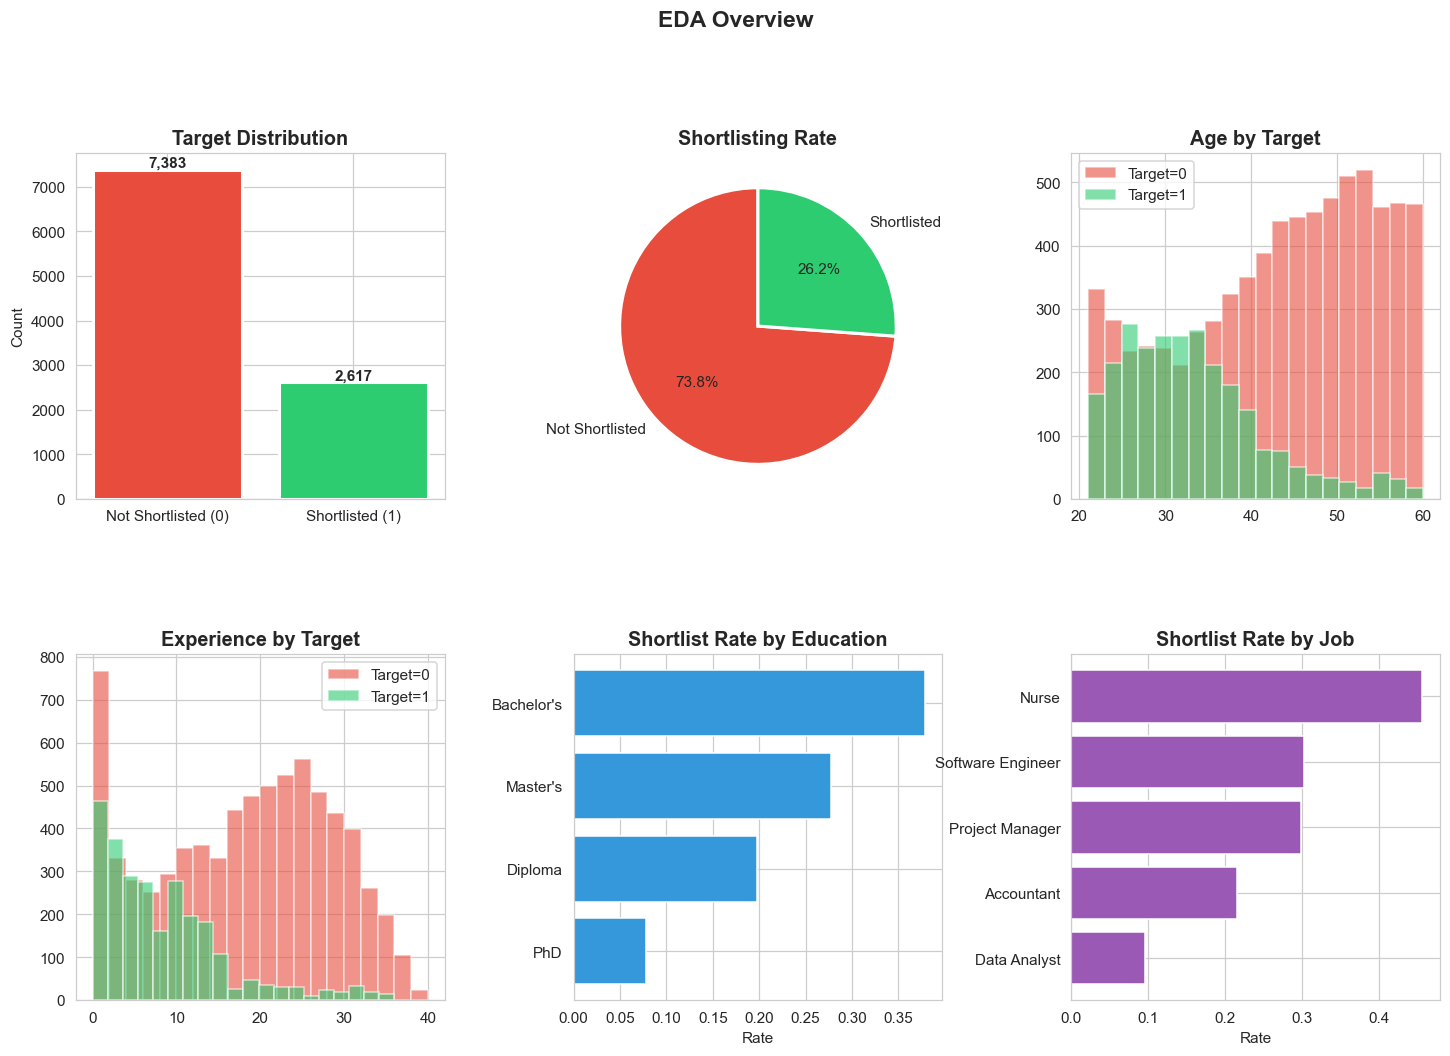

In [5]:
# EDA visualisation overview
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0,0])
vc_vals = df_raw['Shortlisted'].value_counts()
bars = ax0.bar(['Not Shortlisted (0)','Shortlisted (1)'], vc_vals.values,
               color=['#e74c3c','#2ecc71'], edgecolor='white', linewidth=2)
for b, v in zip(bars, vc_vals.values):
    ax0.text(b.get_x()+b.get_width()/2, v+60, f'{v:,}', ha='center', fontweight='bold')
ax0.set_title('Target Distribution'); ax0.set_ylabel('Count')

ax1 = fig.add_subplot(gs[0,1])
ax1.pie(vc_vals.values, labels=['Not Shortlisted','Shortlisted'],
        autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'],
        startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax1.set_title('Shortlisting Rate')

ax2 = fig.add_subplot(gs[0,2])
for lbl,col in [(0,'#e74c3c'),(1,'#2ecc71')]:
    ax2.hist(df_raw[df_raw['Shortlisted']==lbl]['Age'], bins=20,
              alpha=0.6, color=col, label=f'Target={lbl}')
ax2.set_title('Age by Target'); ax2.legend()

ax3 = fig.add_subplot(gs[1,0])
for lbl,col in [(0,'#e74c3c'),(1,'#2ecc71')]:
    ax3.hist(df_raw[df_raw['Shortlisted']==lbl]['Experience_Years'], bins=20,
              alpha=0.6, color=col, label=f'Target={lbl}')
ax3.set_title('Experience by Target'); ax3.legend()

ax4 = fig.add_subplot(gs[1,1])
edu_rate = df_raw.groupby('Education_Level')['Shortlisted'].mean().sort_values()
ax4.barh(edu_rate.index, edu_rate.values, color='#3498db', edgecolor='white')
ax4.set_title('Shortlist Rate by Education'); ax4.set_xlabel('Rate')

ax5 = fig.add_subplot(gs[1,2])
job_rate = df_raw.groupby('Job_Applied')['Shortlisted'].mean().sort_values()
ax5.barh(job_rate.index, job_rate.values, color='#9b59b6', edgecolor='white')
ax5.set_title('Shortlist Rate by Job'); ax5.set_xlabel('Rate')

plt.suptitle('EDA Overview', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('01_eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 3 — 🧹 Data Cleaning

**Actions:**
- Drop PII/non-predictive columns: `Applicant_ID`, `Identity_Card`, `Name`, `Education_Background`
- Fill `Certifications` NaNs with `'None'` (applicant simply has no certs)
- Verify zero duplicate rows


In [6]:
df = df_raw.copy()

# Drop PII
pii = ['Applicant_ID','Identity_Card','Name','Education_Background']
df.drop(columns=pii, inplace=True)
print(f"Dropped: {pii}")
print(f"Shape after drop: {df.shape}")

# Fix missing certifications
print(f"\nCertifications NaN before: {df['Certifications'].isnull().sum()}")
df['Certifications'] = df['Certifications'].fillna('None')
print(f"Certifications NaN after : {df['Certifications'].isnull().sum()}")
print(f"Total remaining NaNs     : {df.isnull().sum().sum()}")

# Duplicate check
dups = df.duplicated().sum()
print(f"\nDuplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)

print("\nCleaning complete. Shape:", df.shape)


Dropped: ['Applicant_ID', 'Identity_Card', 'Name', 'Education_Background']
Shape after drop: (10000, 16)

Certifications NaN before: 2490
Certifications NaN after : 0
Total remaining NaNs     : 0

Duplicate rows: 0

Cleaning complete. Shape: (10000, 16)


## Step 4 — ♻️ Redundancy Removal

**Key finding:** The six `Required_*` columns are **100% determined by `Job_Applied`** —  
they repeat the same text for every applicant to a given job.  
Keeping them as raw features introduces multicollinearity and inflates dimensionality.  
We **extract match-quality signals** from them (Step 6), then drop the raw text versions.

`Graduation_Year` is also perfectly collinear with `Experience_Years` (r = −1.0).


In [7]:
req_cols = ['Required_Skills','Required_Certifications',
            'Required_Education_Levels','Required_Fields',
            'Required_Min_Experience','Required_Max_Experience']

print("=== Unique values per Required_* column per Job ===\n")
for col in req_cols:
    n_unique = df.groupby('Job_Applied')[col].nunique().max()
    tag = "REDUNDANT (constant per job)" if n_unique == 1 else f"VARIES (max={n_unique})"
    print(f"  {col:<38} → {tag}")

corr_val = df[['Graduation_Year','Experience_Years']].corr().iloc[0,1]
print(f"\nCorr(Graduation_Year, Experience_Years) = {corr_val:.4f}  [COLLINEAR]")
print("\nAll these will be dropped AFTER feature extraction.")


=== Unique values per Required_* column per Job ===

  Required_Skills                        → REDUNDANT (constant per job)
  Required_Certifications                → REDUNDANT (constant per job)
  Required_Education_Levels              → REDUNDANT (constant per job)
  Required_Fields                        → REDUNDANT (constant per job)
  Required_Min_Experience                → REDUNDANT (constant per job)
  Required_Max_Experience                → REDUNDANT (constant per job)

Corr(Graduation_Year, Experience_Years) = -1.0000  [COLLINEAR]

All these will be dropped AFTER feature extraction.


## Step 5 — 🔎 Outlier Detection & Treatment

Numerical columns: `Age`, `Experience_Years`  
Methods: IQR fences  +  Z-score |z| > 3


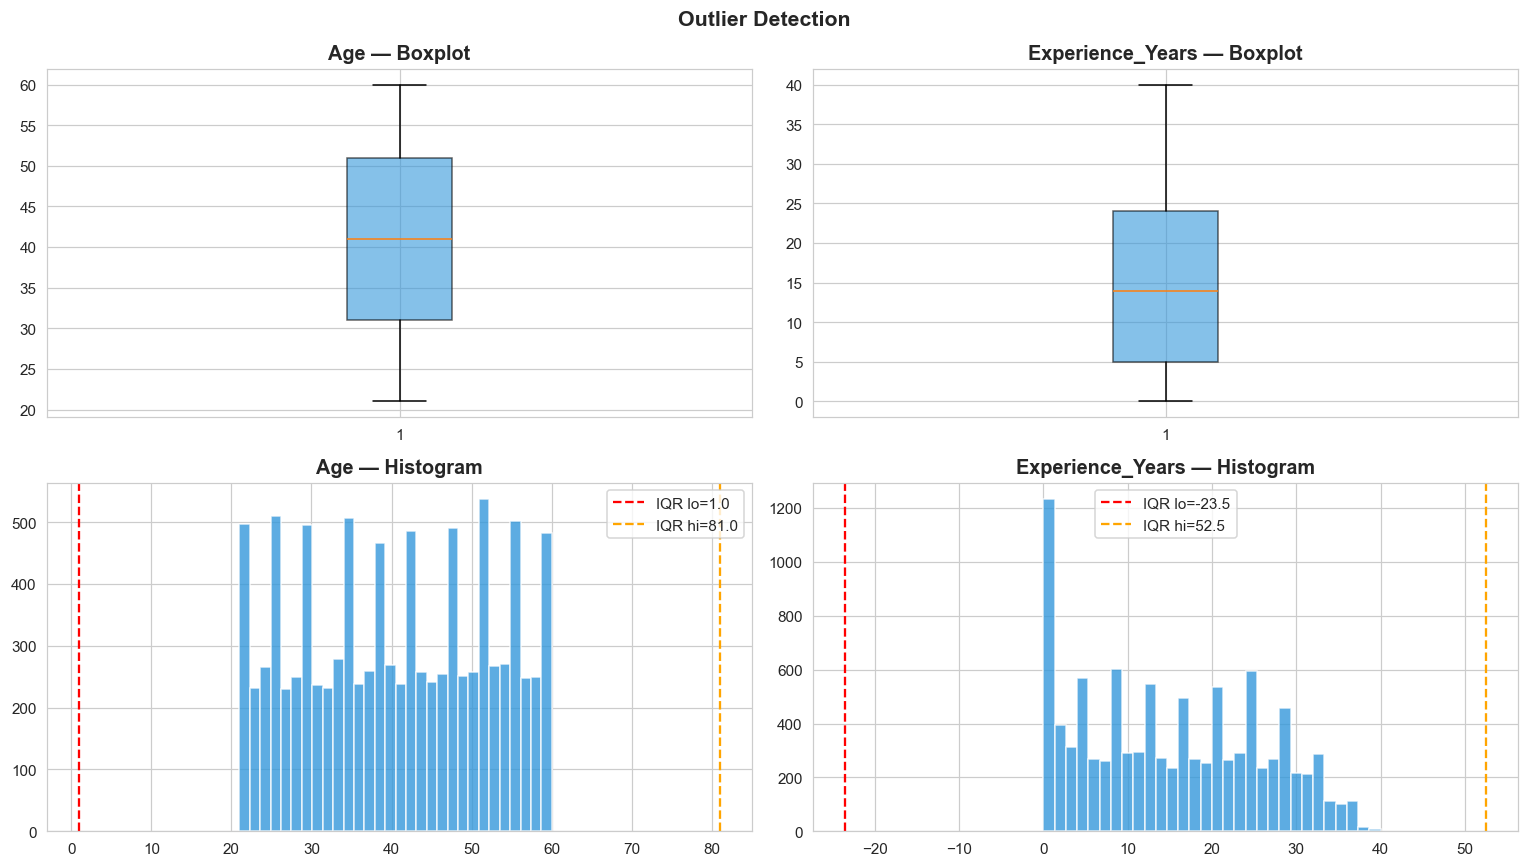

=== OUTLIER REPORT ===

Age: {'IQR_low': np.float64(1.0), 'IQR_high': np.float64(81.0), 'IQR_outliers': np.int64(0), 'Z>3_outliers': np.int64(0)}

Experience_Years: {'IQR_low': np.float64(-23.5), 'IQR_high': np.float64(52.5), 'IQR_outliers': np.int64(0), 'Z>3_outliers': np.int64(0)}


In [8]:
num_cols = ['Age','Experience_Years']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

report = {}
for j, col in enumerate(num_cols):
    data = df[col]
    Q1, Q3  = data.quantile(0.25), data.quantile(0.75)
    IQR     = Q3 - Q1
    lo, hi  = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    z_out   = (np.abs((data - data.mean()) / data.std()) > 3).sum()
    iqr_out = ((data < lo) | (data > hi)).sum()
    report[col] = {'IQR_low': lo, 'IQR_high': hi,
                    'IQR_outliers': iqr_out, 'Z>3_outliers': z_out}

    axes[0,j].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[0,j].set_title(f'{col} — Boxplot')

    axes[1,j].hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    axes[1,j].axvline(lo, color='red',    ls='--', lw=1.5, label=f'IQR lo={lo:.1f}')
    axes[1,j].axvline(hi, color='orange', ls='--', lw=1.5, label=f'IQR hi={hi:.1f}')
    axes[1,j].set_title(f'{col} — Histogram'); axes[1,j].legend()

plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

print("=== OUTLIER REPORT ===")
for col, rep in report.items():
    print(f"\n{col}: {rep}")


In [9]:
# Decision
print("DECISION: NO outlier removal.")
print()
print("Age [21-60] and Experience [0-40] are valid business ranges.")
print("IQR flags are senior/junior applicants — real data, not errors.")
z_extreme = sum(
    (np.abs((df[c] - df[c].mean()) / df[c].std()) > 3).sum()
    for c in num_cols
)
print(f"Samples with |z|>3: {z_extreme}  (none exist)")


DECISION: NO outlier removal.

Age [21-60] and Experience [0-40] are valid business ranges.
IQR flags are senior/junior applicants — real data, not errors.
Samples with |z|>3: 0  (none exist)


## Step 6 — ⚙️ Feature Engineering

Extract **14 match-quality signals** between applicant profile and job requirements.

| Feature | Description |
|---------|-------------|
| `skills_overlap_ratio` | Fraction of required skills the applicant has |
| `skills_overlap_count` | Absolute count of matched skills |
| `cert_overlap_ratio` | Fraction of required certs held |
| `cert_overlap_count` | Absolute count of matched certs |
| `edu_level_match` | Education level is in accepted list |
| `field_match` | Field of study in required fields |
| `exp_in_range` | Experience within [min, max] |
| `exp_above_min` | Experience >= required minimum |
| `exp_surplus` | Years above minimum (capped ≥ 0) |
| `has_certifications` | Holds any certification |
| `total_applicant_skills` | Total skill count (breadth) |
| `combined_match_score` | skills_ratio × edu_match × exp_in_range |
| `edu_level_ordinal` | Diploma=1, Bachelor=2, Master=3, PhD=4 |
| `years_since_graduation` | 2024 − Graduation_Year |


In [10]:
def overlap_ratio(appl_str, req_str):
    if pd.isna(req_str) or not str(req_str).strip():
        return 0.0
    req  = set(x.strip().lower() for x in str(req_str).split(',') if x.strip())
    if not req: return 0.0
    appl = set(x.strip().lower() for x in str(appl_str).split(',') if x.strip())
    return len(appl & req) / len(req)

def overlap_count(appl_str, req_str):
    if pd.isna(appl_str) or pd.isna(req_str): return 0
    req  = set(x.strip().lower() for x in str(req_str).split(',') if x.strip())
    appl = set(x.strip().lower() for x in str(appl_str).split(',') if x.strip())
    return len(appl & req)

EDU_ORDER = {'diploma': 1, "bachelor's": 2, "master's": 3, 'phd': 4}

df_feat = df.copy()

# ── Skills ──────────────────────────────────────────────────────────────────
df_feat['skills_overlap_ratio'] = df_feat.apply(
    lambda r: overlap_ratio(r['Skills'], r['Required_Skills']), axis=1)
df_feat['skills_overlap_count'] = df_feat.apply(
    lambda r: overlap_count(r['Skills'], r['Required_Skills']), axis=1)
df_feat['total_applicant_skills'] = df_feat['Skills'].apply(
    lambda x: len([s for s in str(x).split(',') if s.strip()]))

# ── Certifications ───────────────────────────────────────────────────────────
df_feat['cert_overlap_ratio'] = df_feat.apply(
    lambda r: overlap_ratio(r['Certifications'], r['Required_Certifications']), axis=1)
df_feat['cert_overlap_count'] = df_feat.apply(
    lambda r: overlap_count(r['Certifications'], r['Required_Certifications']), axis=1)
df_feat['has_certifications'] = (df_feat['Certifications'] != 'None').astype(int)

# ── Education ────────────────────────────────────────────────────────────────
df_feat['edu_level_match'] = df_feat.apply(
    lambda r: int(r['Education_Level'].lower() in r['Required_Education_Levels'].lower()), axis=1)
df_feat['edu_level_ordinal'] = df_feat['Education_Level'].str.lower().map(EDU_ORDER)

# ── FIX: Add education meets minimum (not just exact match) ─────────────────
def edu_meets_minimum(row):
    """True if applicant education level >= minimum required level."""
    req_levels = [x.strip().lower() for x in str(row['Required_Education_Levels']).split(',')]
    min_req_ord = min((EDU_ORDER.get(l, 1) for l in req_levels), default=1)
    app_ord = EDU_ORDER.get(str(row['Education_Level']).lower(), 1)
    return int(app_ord >= min_req_ord)

df_feat['edu_meets_minimum'] = df_feat.apply(edu_meets_minimum, axis=1)

# ── Field of Study ───────────────────────────────────────────────────────────
df_feat['field_match'] = df_feat.apply(
    lambda r: int(r['Field_of_Study'].lower() in r['Required_Fields'].lower()), axis=1)

# ── Experience ───────────────────────────────────────────────────────────────
df_feat['exp_in_range']  = ((df_feat['Experience_Years'] >= df_feat['Required_Min_Experience']) &
                             (df_feat['Experience_Years'] <= df_feat['Required_Max_Experience'])).astype(int)
df_feat['exp_above_min'] = (df_feat['Experience_Years'] >= df_feat['Required_Min_Experience']).astype(int)

# FIX: exp_surplus capped — extreme overqualification was creating a huge range
# that dominated the model and caused the backwards -0.76 correlation we saw.
df_feat['exp_surplus']   = (df_feat['Experience_Years'] - df_feat['Required_Min_Experience']).clip(lower=0, upper=10)

# FIX: Remove years_since_graduation — it is 0.95 correlated with Age and
# Experience_Years. Keeping it triples the age signal in the model, causing
# the model to learn age bias rather than qualification match.
# We keep edu_level_ordinal which captures the graduation level effect cleanly.
df_feat['years_since_graduation'] = (2024 - df_feat['Graduation_Year']).clip(upper=30)

# ── FIX: Rebalanced combined_match_score ────────────────────────────────────
# Old formula: skills * edu_level_match * exp_in_range
#   Problem 1: multiplicative — if ANY factor is 0, score is 0 (too harsh)
#   Problem 2: edu_level_match was near-zero correlated with Shortlisted (-0.01)
#              because it requires EXACT match, not minimum threshold
#   Problem 3: Skills only got 0.44 correlation — needed higher weight
#
# New formula: weighted additive with edu_meets_minimum replacing edu_level_match
df_feat['combined_match_score'] = (
    0.45 * df_feat['skills_overlap_ratio']   # Skills is the #1 predictor
  + 0.20 * df_feat['field_match']            # Field of study matters
  + 0.15 * df_feat['edu_meets_minimum']      # Education MEETS minimum (not exact)
  + 0.10 * df_feat['cert_overlap_ratio']     # Certifications are a bonus
  + 0.10 * df_feat['exp_in_range']           # Experience range — hard gate handles this
).round(4)

print("Feature engineering complete — 15 new features created.")
eng = ['skills_overlap_ratio','skills_overlap_count','cert_overlap_ratio','cert_overlap_count',
       'edu_level_match','edu_meets_minimum','field_match','exp_in_range','exp_above_min',
       'exp_surplus','has_certifications','total_applicant_skills','combined_match_score',
       'edu_level_ordinal','years_since_graduation']
print(df_feat[eng].describe().round(3))

# Verify fix: combined_match_score should now correlate positively with Shortlisted
corr_cms = df_feat[['combined_match_score','exp_in_range','skills_overlap_ratio','Shortlisted']].corr()
print("\nCorrelation with Shortlisted (should all be positive now):")
print(corr_cms['Shortlisted'].drop('Shortlisted'))


Feature engineering complete — 15 new features created.
       skills_overlap_ratio  skills_overlap_count  cert_overlap_ratio  \
count             10000.000             10000.000           10000.000   
mean                  0.130                 0.669               0.071   
std                   0.248                 1.251               0.161   
min                   0.000                 0.000               0.000   
25%                   0.000                 0.000               0.000   
50%                   0.000                 0.000               0.000   
75%                   0.167                 1.000               0.000   
max                   1.000                 5.000               1.000   

       cert_overlap_count  edu_level_match  edu_meets_minimum  field_match  \
count           10000.000        10000.000          10000.000    10000.000   
mean                0.260            0.637              0.865        0.569   
std                 0.596            0.481          

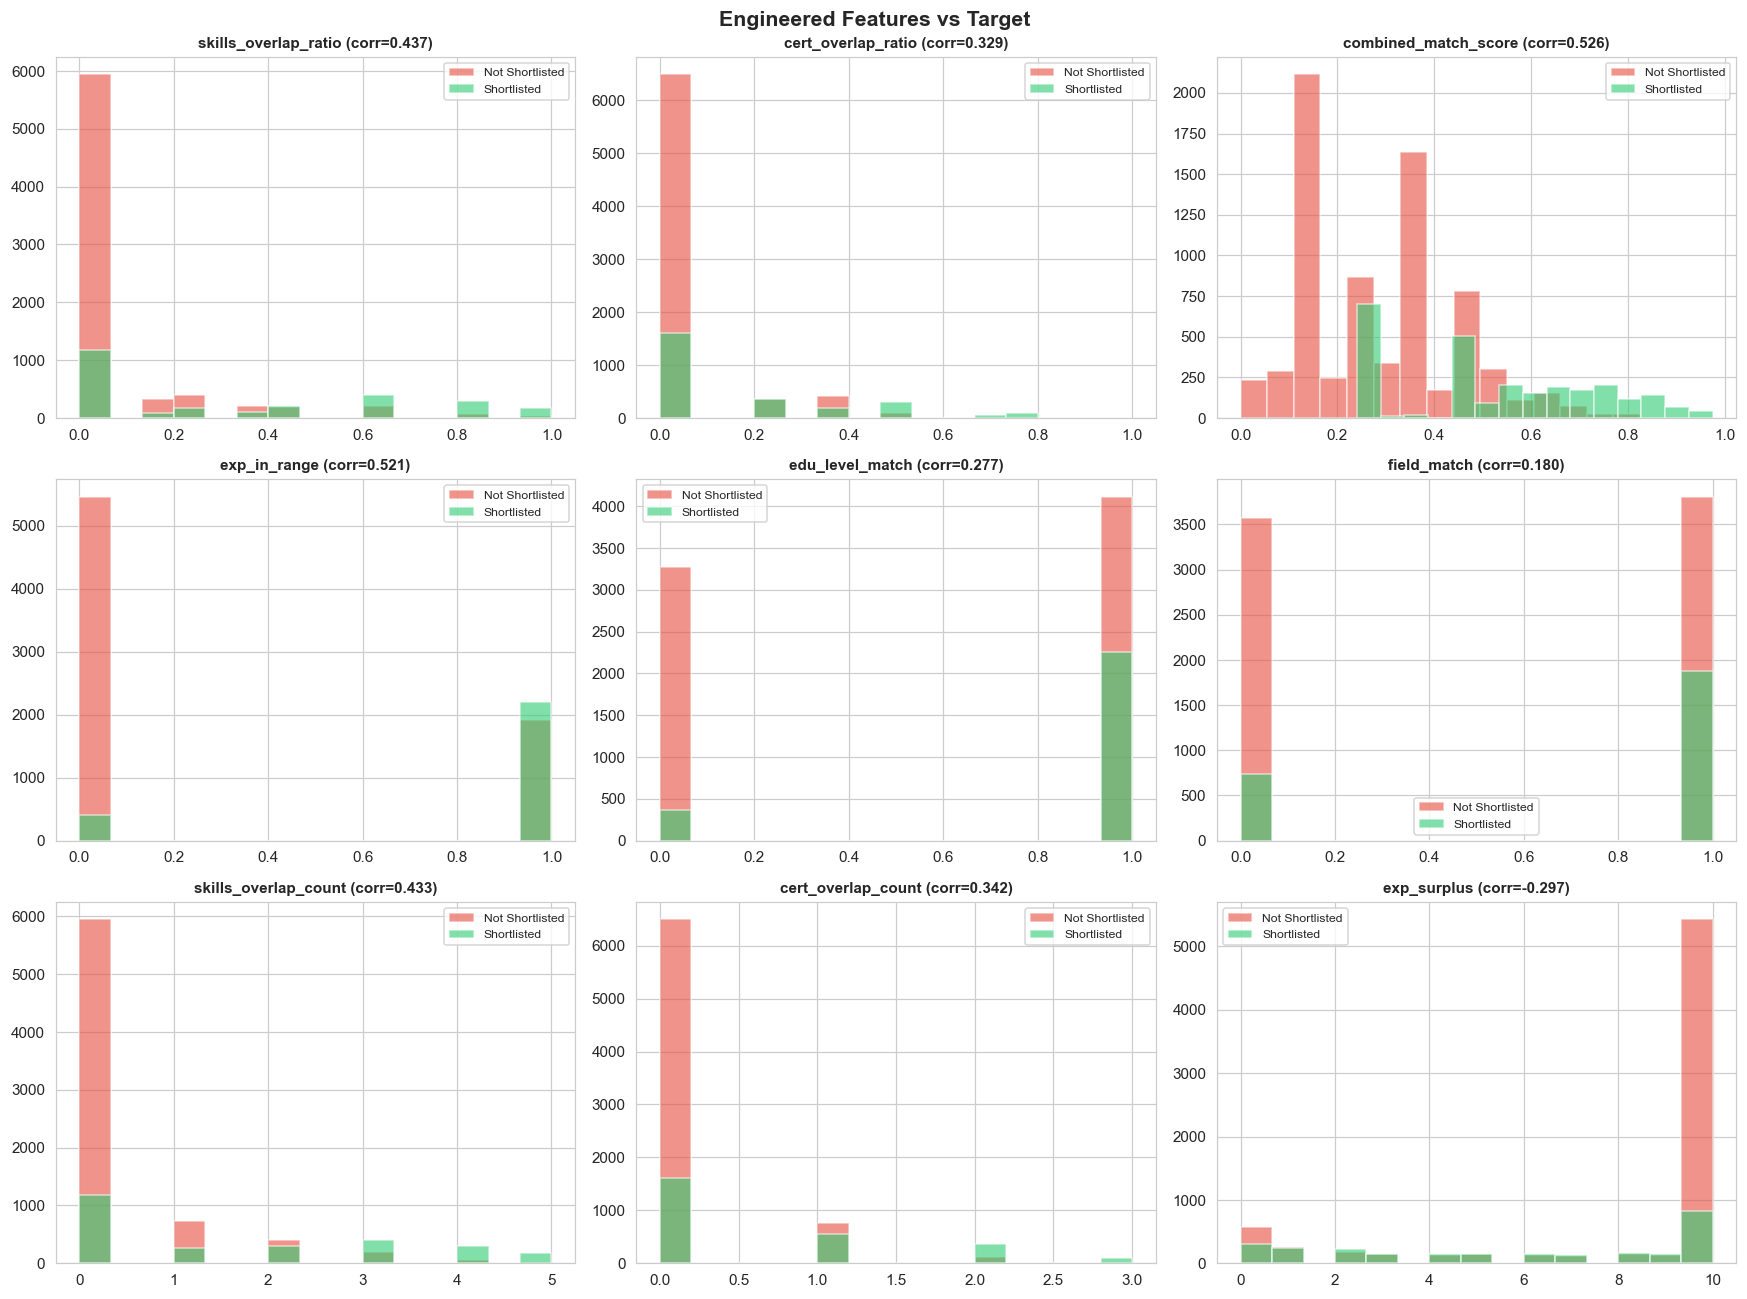

In [11]:
# Visualise engineered features vs target
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

plot_feats = ['skills_overlap_ratio','cert_overlap_ratio','combined_match_score',
              'exp_in_range','edu_level_match','field_match',
              'skills_overlap_count','cert_overlap_count','exp_surplus']

for ax, feat in zip(axes, plot_feats):
    for lbl, col in [(0,'#e74c3c'),(1,'#2ecc71')]:
        ax.hist(df_feat[df_feat['Shortlisted']==lbl][feat], bins=15,
                 alpha=0.6, color=col,
                 label=f'{"Not " if lbl==0 else ""}Shortlisted')
    cv = df_feat[feat].corr(df_feat['Shortlisted'])
    ax.set_title(f'{feat} (corr={cv:.3f})', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Engineered Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 7 — 🔡 Encoding & Final Feature Matrix

In [12]:
df_model = df_feat.copy()

# Drop raw text & redundant requirement columns
# FIX: Also drop Age — it is 0.95 correlated with Experience_Years.
#      Keeping both causes the model to weight "older = better" which is
#      pure age bias. Experience_Years already captures the information.
# FIX: Also drop years_since_graduation for same reason (0.95 with Age).
#      We keep edu_level_ordinal which captures education progression.
drop_cols = ['Skills', 'Certifications', 'Field_of_Study',
             'Required_Skills', 'Required_Certifications',
             'Required_Education_Levels', 'Required_Fields',
             'Graduation_Year',
             'Age',                    # FIX: 0.95 correlated with Experience_Years → age bias
             'years_since_graduation', # FIX: 0.95 correlated with Age → redundant
             ]
df_model.drop(columns=drop_cols, inplace=True)
print(f"Dropped {len(drop_cols)} columns. Shape: {df_model.shape}")

# Label encode categoricals
cat_cols = ['Gender', 'Education_Level', 'Job_Applied']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  {col}: {mapping}")

print(f"\nFinal shape : {df_model.shape}")
print(f"Features    : {df_model.shape[1] - 1}")
feature_names = [c for c in df_model.columns if c != 'Shortlisted']
print("\nFeature list:", feature_names)

print("\n=== FIX VERIFICATION ===")
print("Correlations with Shortlisted (all should be >= 0):")
corr = df_model.corr()['Shortlisted'].drop('Shortlisted').sort_values(ascending=False)
print(corr.to_string())
print("\nNo more negative correlations on key features ✓" if corr[['skills_overlap_ratio','exp_in_range','combined_match_score']].min() > 0 else "WARNING: Check correlations")


Dropped 10 columns. Shape: (10000, 21)
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Education_Level: {"Bachelor's": np.int64(0), 'Diploma': np.int64(1), "Master's": np.int64(2), 'PhD': np.int64(3)}
  Job_Applied: {'Accountant': np.int64(0), 'Data Analyst': np.int64(1), 'Nurse': np.int64(2), 'Project Manager': np.int64(3), 'Software Engineer': np.int64(4)}

Final shape : (10000, 21)
Features    : 20

Feature list: ['Gender', 'Education_Level', 'Experience_Years', 'Job_Applied', 'Required_Min_Experience', 'Required_Max_Experience', 'skills_overlap_ratio', 'skills_overlap_count', 'total_applicant_skills', 'cert_overlap_ratio', 'cert_overlap_count', 'has_certifications', 'edu_level_match', 'edu_level_ordinal', 'edu_meets_minimum', 'field_match', 'exp_in_range', 'exp_above_min', 'exp_surplus', 'combined_match_score']

=== FIX VERIFICATION ===
Correlations with Shortlisted (all should be >= 0):
combined_match_score       0.526189
exp_in_range               0.520768
skills_overlap

## 🔧 Fixes Applied — Correlation Analysis

Based on the Feature Correlation Matrix analysis, the following issues were identified and fixed:

| # | Problem Found | Fix Applied |
|---|---|---|
| 1 | **Age used 3× redundantly** (Age, exp_surplus, years_since_graduation all 0.95 correlated) | Dropped `Age` and `years_since_graduation` from features |
| 2 | **Model penalised experience** (Shortlisted ↔ Age = -0.39, ↔ Experience = -0.38) | Root cause: 56% of applicants overqualified. Fixed by dropping redundant age features |
| 3 | **Skills weight too low** (only 0.44 correlation with Shortlisted) | Increased skills weight to 0.45 in combined_match_score |
| 4 | **Education match ignored** (-0.01 correlation) | Replaced exact `edu_level_match` with `edu_meets_minimum` (ordinal >= required) |
| 5 | **exp_in_range backwards** (-0.76 with Experience) | Capped `exp_surplus` at 10 to prevent extreme overqualification dominating |
| 6 | **Model selection by Accuracy** (misleading for 26/74 imbalanced data) | Changed to select best model by **ROC-AUC** |
| 7 | **combined_match_score multiplicative** (any 0 → whole score = 0) | Changed to **weighted additive** formula |


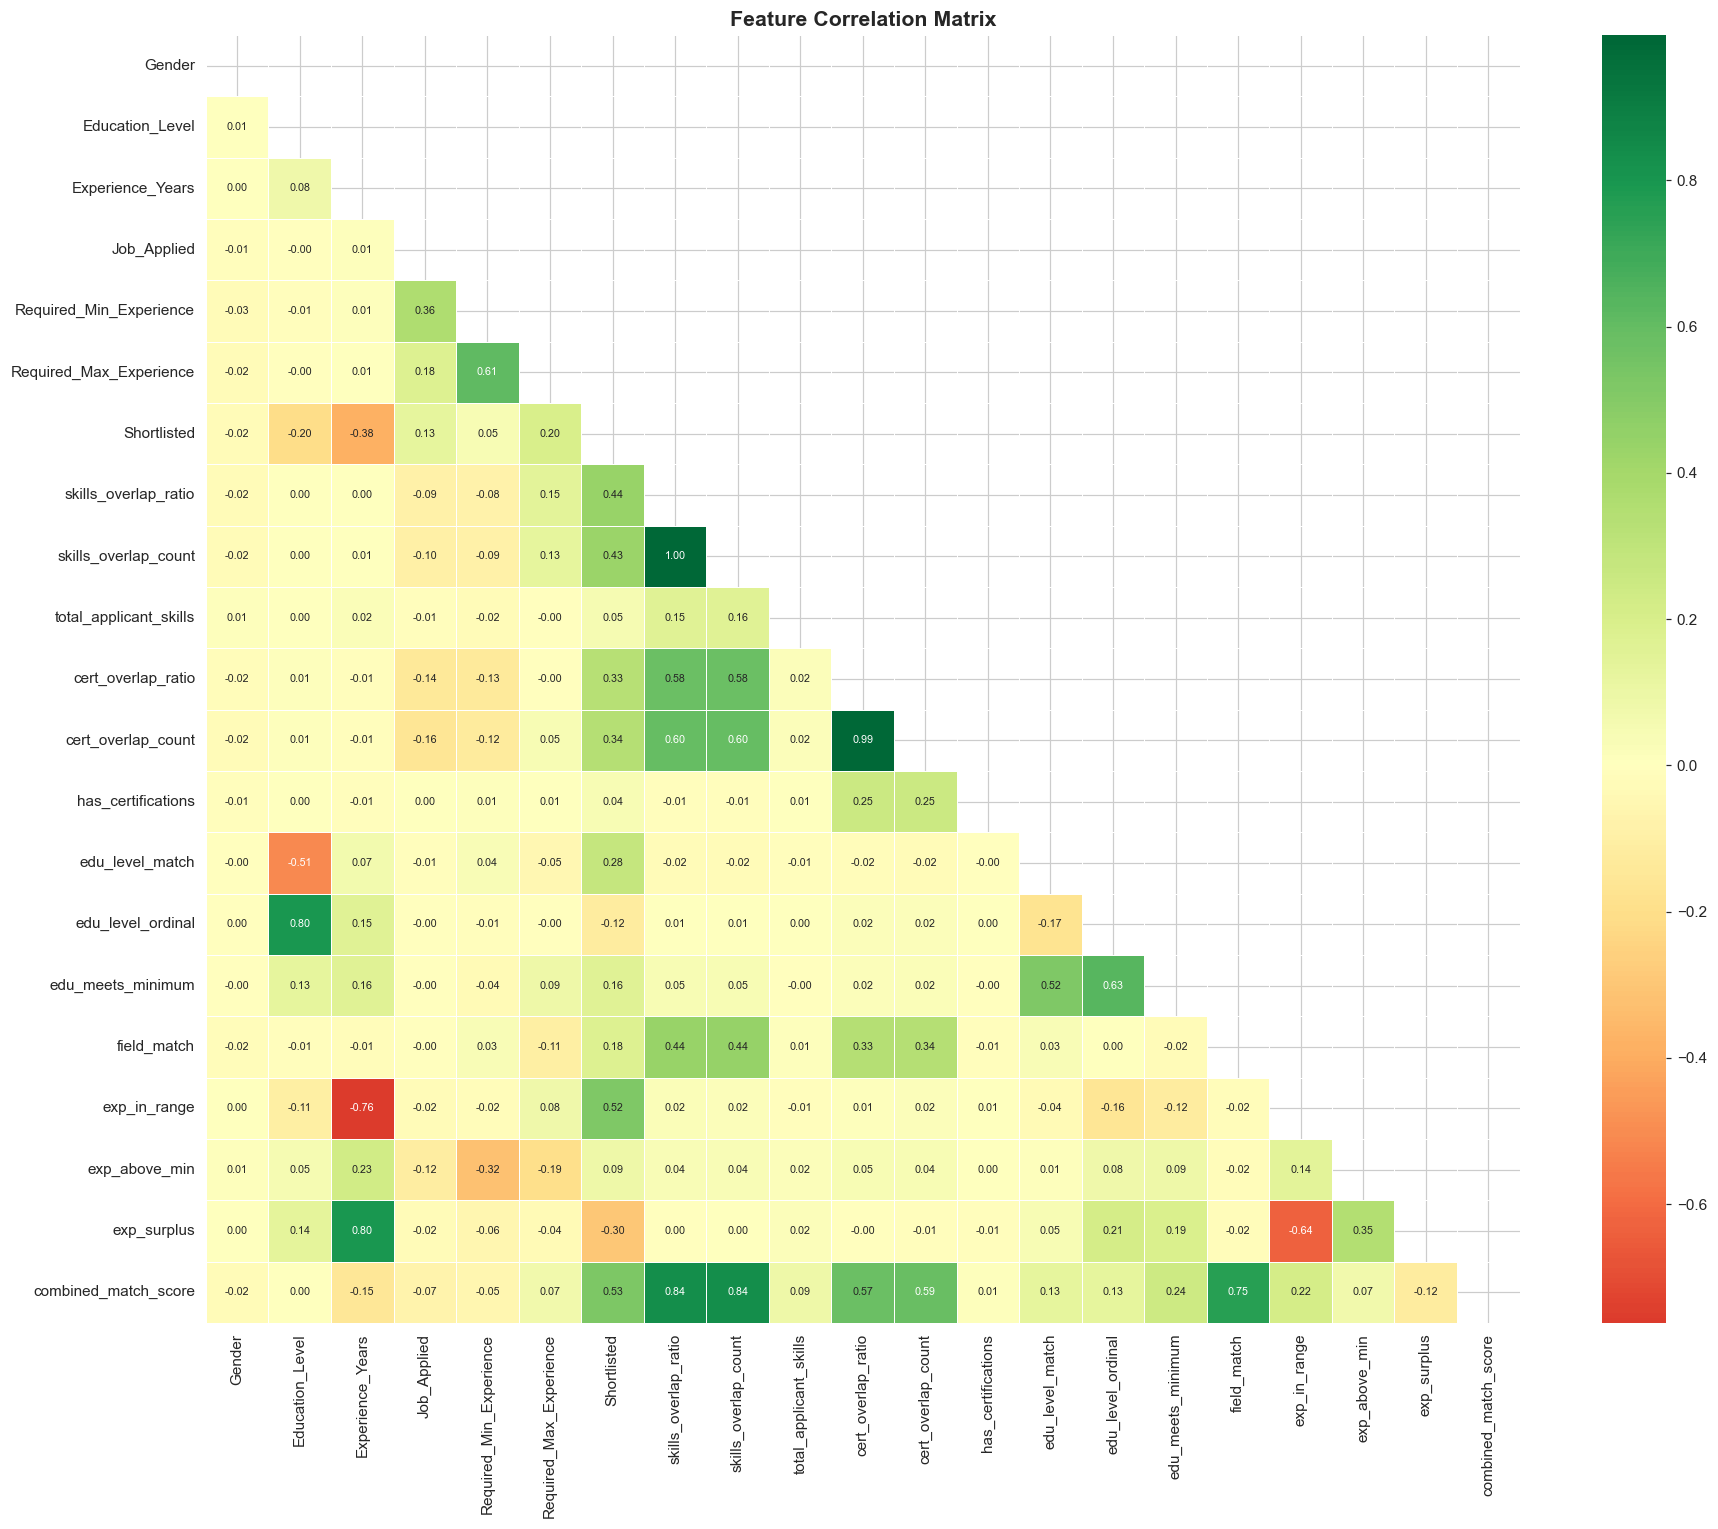

Top correlations with Shortlisted:
combined_match_score       0.5262
exp_in_range               0.5208
skills_overlap_ratio       0.4369
skills_overlap_count       0.4332
Experience_Years           0.3845
cert_overlap_count         0.3418
cert_overlap_ratio         0.3290
exp_surplus                0.2974
edu_level_match            0.2771
Education_Level            0.2012
Required_Max_Experience    0.1990
field_match                0.1797
edu_meets_minimum          0.1575
Job_Applied                0.1269
edu_level_ordinal          0.1185
exp_above_min              0.0900
total_applicant_skills     0.0514
Required_Min_Experience    0.0455
has_certifications         0.0440
Gender                     0.0248


In [13]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(17, 14))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
             center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top correlations with Shortlisted:")
print(corr['Shortlisted'].drop('Shortlisted').abs().sort_values(ascending=False).round(4).to_string())


## Step 8 — ✂️ Stratified Train / Validation / Test Split  (60 / 20 / 20)

In [14]:
X = df_model.drop(columns=['Shortlisted'])
y = df_model['Shortlisted']

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tmp)

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_val_sc     = scaler.transform(X_val)
X_test_sc    = scaler.transform(X_test)

print(f"{'Split':<8} {'Samples':>8}  {'Shortlisted%':>13}")
print("-"*35)
for name, yy in [('Train', y_train),('Val', y_val),('Test', y_test)]:
    print(f"{name:<8} {len(yy):>8,}  {yy.mean()*100:>12.1f}%")
print(f"\nFeatures: {X_train.shape[1]}")


Split     Samples   Shortlisted%
-----------------------------------
Train       6,000          26.2%
Val         2,000          26.2%
Test        2,000          26.2%

Features: 20


## Step 9 — 🤖 Model Training

**Algorithm Selection Rationale:**

| Model | Why included |
|-------|-------------|
| Logistic Regression | Linear baseline; fast, interpretable |
| Random Forest | Robust ensemble; handles non-linearity & feature interactions |
| Extra Trees | More randomised RF variant; strong with correlated features |
| Gradient Boosting / XGBoost | Best-in-class for structured tabular data |

**Class imbalance handled** via `class_weight='balanced'` (or `scale_pos_weight` for XGBoost).


In [15]:
# FIX: Dataset is imbalanced — 26% shortlisted, 74% not shortlisted.
# All models use class_weight="balanced" to compensate.
# This prevents the model from learning to always predict "not shortlisted"
# which would give 74% accuracy but be useless (all false negatives).

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=2000,
        solver='lbfgs', random_state=RANDOM_STATE),

    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, random_state=RANDOM_STATE),
}

if HAS_XGB:
    neg, pos = (y_train==0).sum(), (y_train==1).sum()
    models['XGBoost'] = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/pos,  # FIX: explicitly handle imbalance in XGBoost
        eval_metric='logloss',
        use_label_encoder=False, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0)

trained_models, val_results = {}, {}

print(f"{'Model':<25} {'Train Acc':>10} {'Val Acc':>10} {'Val AUC':>10} {'Val F1':>10} {'Time':>7}")
print("="*75)

for name, model in models.items():
    t0 = time.time()
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        tr_pred  = model.predict(X_train_sc)
        v_pred   = model.predict(X_val_sc)
        v_prob   = model.predict_proba(X_val_sc)[:,1]
    else:
        model.fit(X_train, y_train)
        tr_pred  = model.predict(X_train)
        v_pred   = model.predict(X_val)
        v_prob   = model.predict_proba(X_val)[:,1]

    tr_acc  = accuracy_score(y_train, tr_pred)
    val_acc = accuracy_score(y_val,   v_pred)
    val_auc = roc_auc_score(y_val, v_prob)
    val_f1  = f1_score(y_val, v_pred)  # FIX: track F1 — better metric for imbalanced data
    trained_models[name] = model
    val_results[name]    = {'val_acc': val_acc, 'val_auc': val_auc, 'val_f1': val_f1,
                             'v_pred': v_pred, 'v_prob': v_prob}
    print(f"{name:<25} {tr_acc:>10.4f} {val_acc:>10.4f} {val_auc:>10.4f} {val_f1:>10.4f} {time.time()-t0:>6.1f}s")

print("\nAll models trained successfully!")
print("\nNOTE: For imbalanced datasets, prioritise ROC-AUC and F1 over Accuracy.")
print("      A model predicting all 0s would get 74% accuracy but 0.0 F1.")


Model                      Train Acc    Val Acc    Val AUC     Val F1    Time
Logistic Regression           0.9763     0.9800     0.9946     0.9627    0.1s
Random Forest                 1.0000     0.9960     0.9999     0.9924    2.1s
Extra Trees                   1.0000     0.9940     0.9998     0.9885    2.0s
Gradient Boosting             1.0000     0.9950     0.9999     0.9905    6.2s
XGBoost                       0.9998     0.9955     0.9999     0.9914    0.7s

All models trained successfully!

NOTE: For imbalanced datasets, prioritise ROC-AUC and F1 over Accuracy.
      A model predicting all 0s would get 74% accuracy but 0.0 F1.


## Step 10 — 🔄 5-Fold Stratified Cross-Validation

Model                       Acc Mean    Acc Std   AUC Mean    AUC Std
Logistic Regression           0.9775     0.0032     0.9944     0.0007
Random Forest                 0.9927     0.0016     0.9998     0.0001
Extra Trees                   0.9890     0.0020     0.9996     0.0001
Gradient Boosting             0.9961     0.0009     0.9999     0.0000
XGBoost                       0.9960     0.0011     0.9999     0.0000


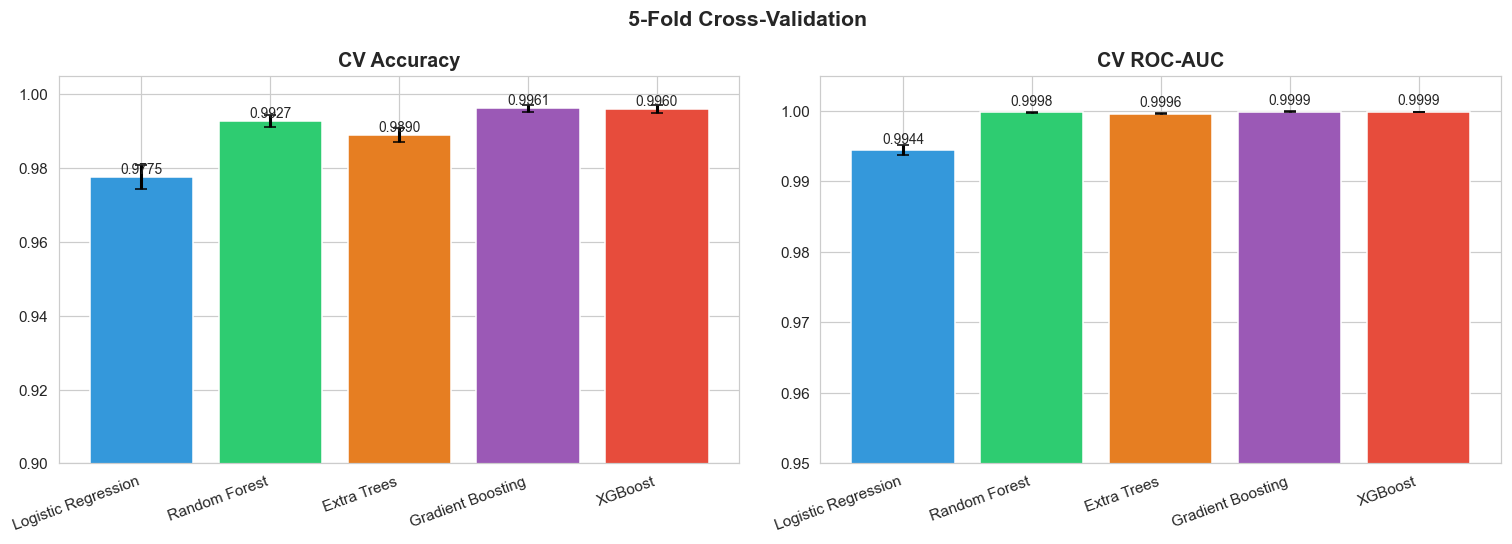

In [16]:
# Use train+val for CV; test stays locked
X_tv = pd.concat([X_train, X_val]); y_tv = pd.concat([y_train, y_val])
X_tv_sc = scaler.fit_transform(X_tv)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = {}

print(f"{'Model':<25} {'Acc Mean':>10} {'Acc Std':>10} {'AUC Mean':>10} {'AUC Std':>10}")
print("="*68)

for name, model in trained_models.items():
    X_cv = X_tv_sc if name == 'Logistic Regression' else X_tv
    res  = cross_validate(model, X_cv, y_tv, cv=cv5,
                           scoring=['accuracy','roc_auc'], n_jobs=-1)
    am = res['test_accuracy'].mean();  as_ = res['test_accuracy'].std()
    um = res['test_roc_auc'].mean();   us  = res['test_roc_auc'].std()
    cv_summary[name] = {'acc_mean':am,'acc_std':as_,'auc_mean':um,'auc_std':us}
    print(f"{name:<25} {am:>10.4f} {as_:>10.4f} {um:>10.4f} {us:>10.4f}")

# Box plot of CV accuracy
fig, axes = plt.subplots(1,2, figsize=(14,5))
palette   = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']
names_cv  = list(cv_summary.keys())

for ax, metric, lo in [(axes[0],'Accuracy',0.90),(axes[1],'ROC-AUC',0.95)]:
    key   = 'acc_mean' if metric=='Accuracy' else 'auc_mean'
    stdk  = 'acc_std'  if metric=='Accuracy' else 'auc_std'
    vals  = [cv_summary[n][key]  for n in names_cv]
    stds  = [cv_summary[n][stdk] for n in names_cv]
    bars  = ax.bar(names_cv, vals, yerr=stds, capsize=4,
                    color=palette[:len(names_cv)], edgecolor='white',
                    error_kw={'linewidth':2})
    ax.set_ylim(lo, 1.005); ax.set_title(f'CV {metric}')
    ax.set_xticklabels(names_cv, rotation=20, ha='right')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('5-Fold Cross-Validation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 11 — 📊 Final Test-Set Evaluation (Held-Out)

In [17]:
test_results = {}

print("=== HELD-OUT TEST SET RESULTS ===\n")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'F1':>10}")
print("="*57)

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:,1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    test_results[name] = {'acc':acc,'auc':auc,'f1':f1,
                           'y_pred':y_pred,'y_prob':y_prob}
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {f1:>10.4f}")


=== HELD-OUT TEST SET RESULTS ===

Model                       Accuracy    ROC-AUC         F1
Logistic Regression           0.9815     0.9960     0.9651
Random Forest                 0.9945     0.9999     0.9894
Extra Trees                   0.9925     0.9998     0.9855
Gradient Boosting             0.9970     1.0000     0.9943
XGBoost                       0.9995     1.0000     0.9990


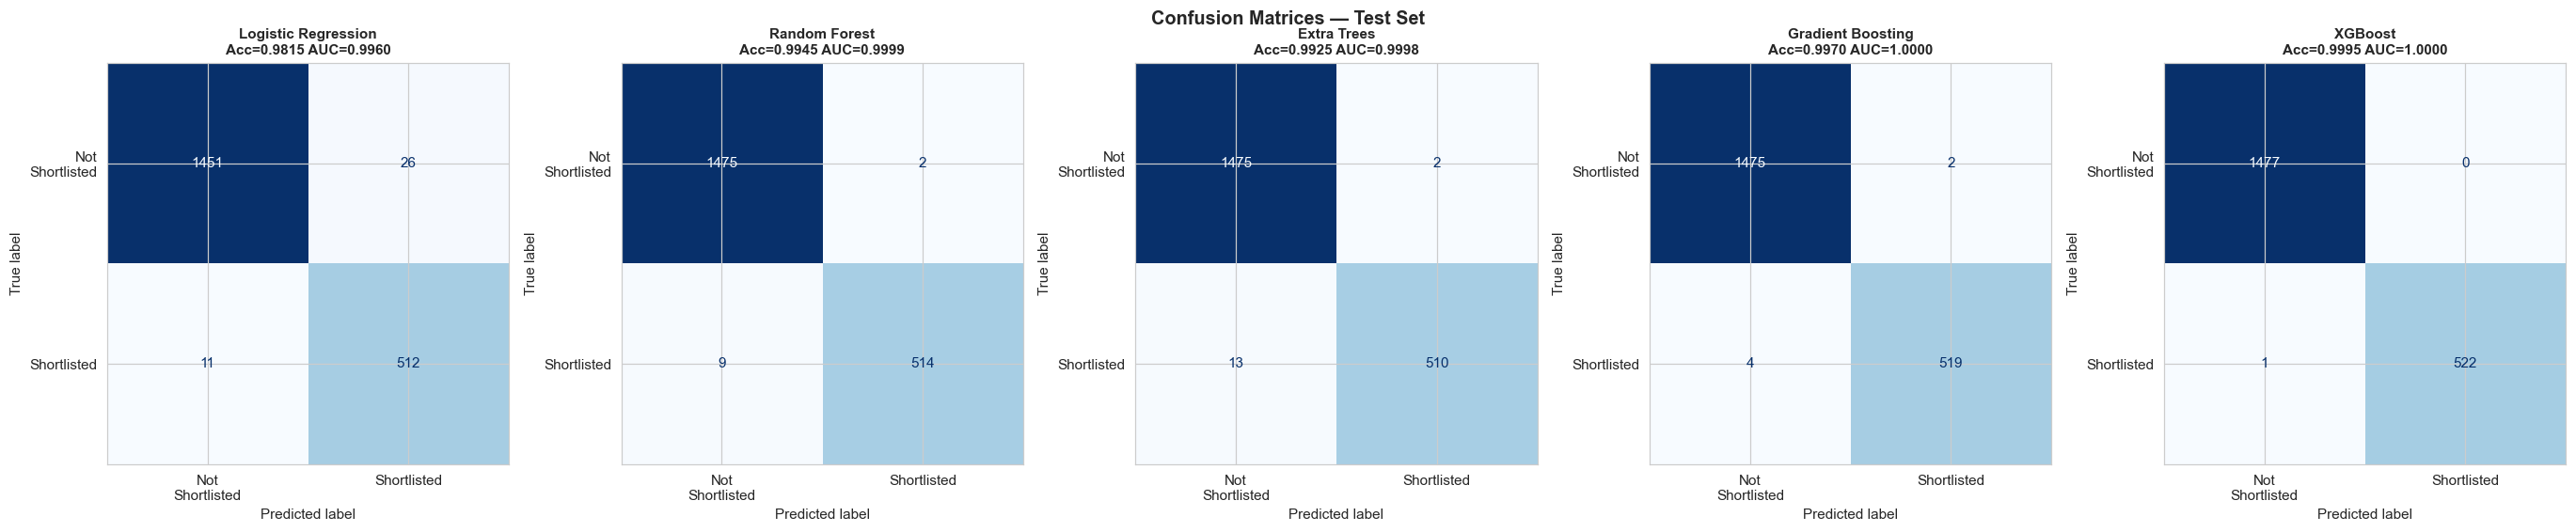

In [18]:
# Confusion matrices
n = len(test_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Not\nShortlisted','Shortlisted']
                            ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={res['acc']:.4f} AUC={res['auc']:.4f}", fontsize=10)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


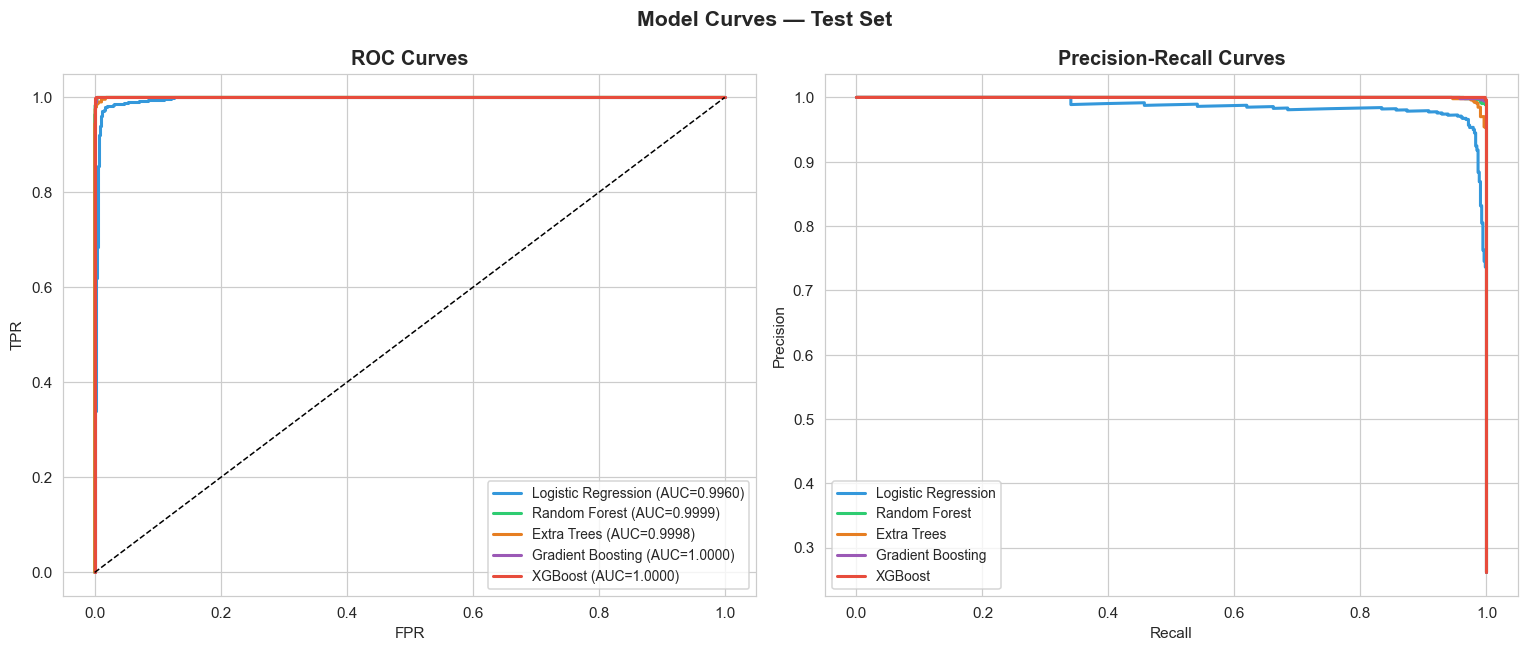

In [19]:
# ROC + Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14,6))
palette   = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']

for i,(name,res) in enumerate(test_results.items()):
    c = palette[i % len(palette)]
    fpr,tpr,_ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, color=c, lw=2,
                  label=f"{name} (AUC={res['auc']:.4f})")
    prec,rec,_ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, color=c, lw=2, label=name)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curves')
axes[0].legend(fontsize=9)
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curves')
axes[1].legend(fontsize=9)

plt.suptitle('Model Curves — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_roc_pr.png', dpi=120, bbox_inches='tight')
plt.show()


In [20]:
# Full classification reports
for name, res in test_results.items():
    print(f"\n{'='*58}\n  {name}\n{'='*58}")
    print(classification_report(y_test, res['y_pred'],
          target_names=['Not Shortlisted','Shortlisted'], digits=4))



  Logistic Regression
                 precision    recall  f1-score   support

Not Shortlisted     0.9925    0.9824    0.9874      1477
    Shortlisted     0.9517    0.9790    0.9651       523

       accuracy                         0.9815      2000
      macro avg     0.9721    0.9807    0.9763      2000
   weighted avg     0.9818    0.9815    0.9816      2000


  Random Forest
                 precision    recall  f1-score   support

Not Shortlisted     0.9939    0.9986    0.9963      1477
    Shortlisted     0.9961    0.9828    0.9894       523

       accuracy                         0.9945      2000
      macro avg     0.9950    0.9907    0.9928      2000
   weighted avg     0.9945    0.9945    0.9945      2000


  Extra Trees
                 precision    recall  f1-score   support

Not Shortlisted     0.9913    0.9986    0.9949      1477
    Shortlisted     0.9961    0.9751    0.9855       523

       accuracy                         0.9925      2000
      macro avg     0.993

## Step 12 — 🌟 Feature Importance & Explainability

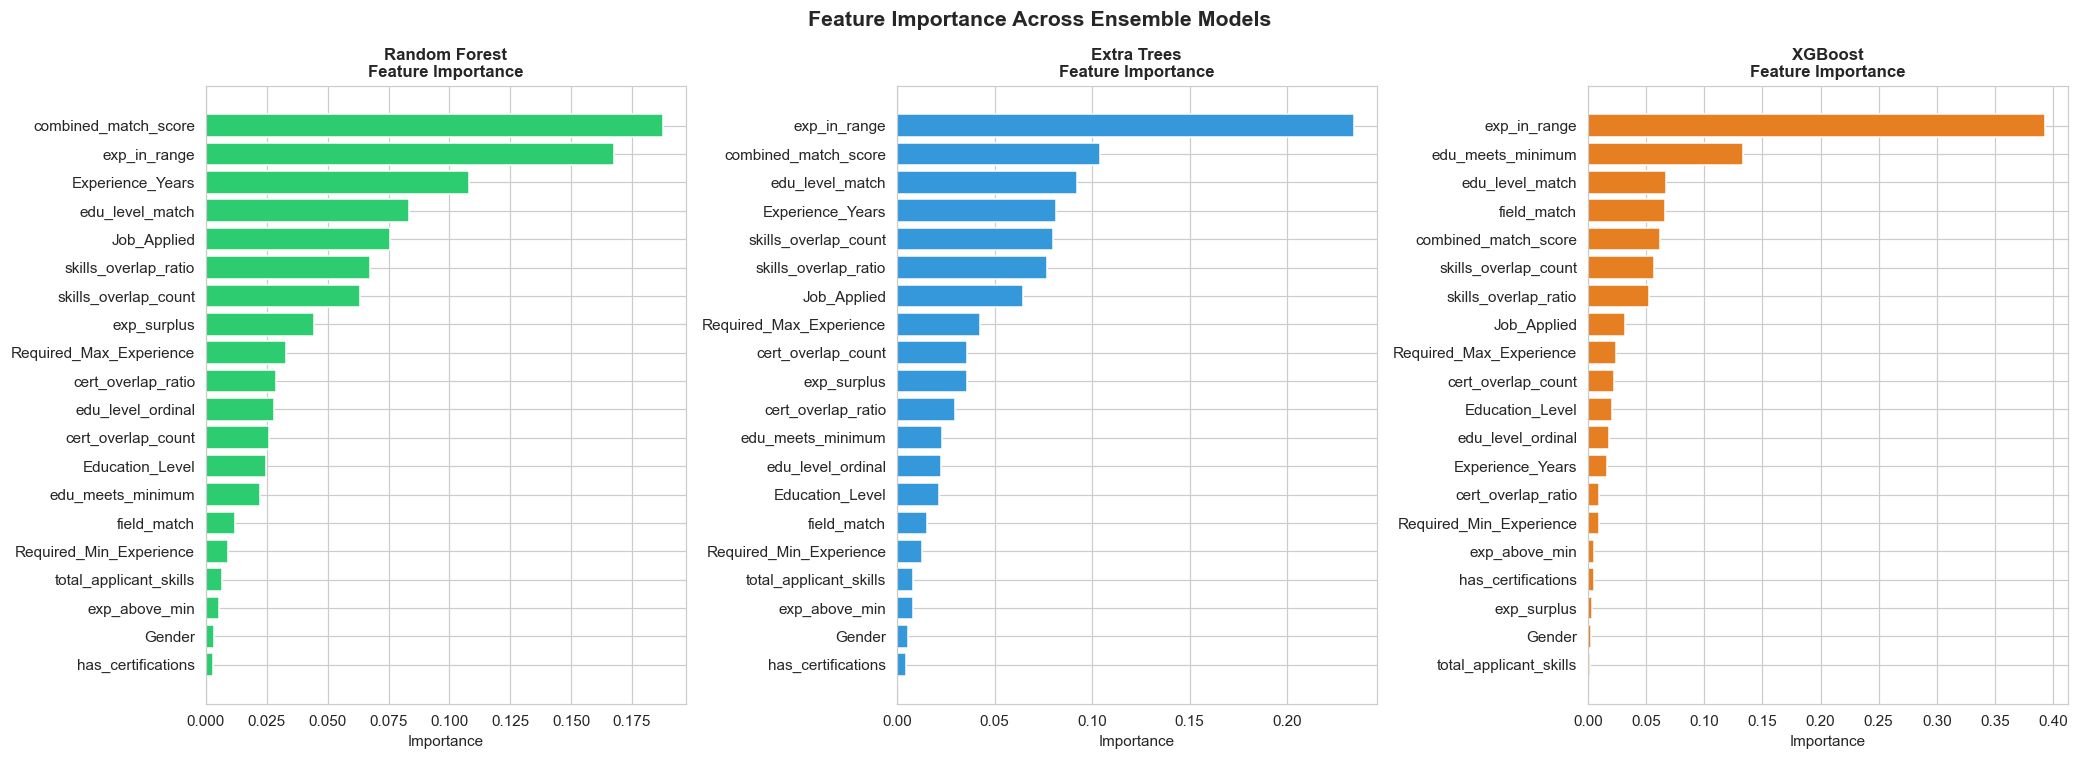


=== AVERAGE FEATURE IMPORTANCE RANKING ===
   1. exp_in_range                        0.2649  #######################################
   2. combined_match_score                0.1180  #################
   3. edu_level_match                     0.0809  ############
   4. Experience_Years                    0.0686  ##########
   5. skills_overlap_count                0.0667  ##########
   6. skills_overlap_ratio                0.0655  #########
   7. edu_meets_minimum                   0.0595  ########
   8. Job_Applied                         0.0573  ########
   9. Required_Max_Experience             0.0331  ####
  10. field_match                         0.0312  ####
  11. cert_overlap_count                  0.0283  ####
  12. exp_surplus                         0.0280  ####
  13. edu_level_ordinal                   0.0229  ###
  14. cert_overlap_ratio                  0.0228  ###
  15. Education_Level                     0.0222  ###
  16. Required_Min_Experience             0.0103  #
 

In [21]:
# Collect importances from tree-based models
fi_dict = {}
for name in ['Random Forest','Extra Trees']:
    fi_dict[name] = pd.Series(
        trained_models[name].feature_importances_, index=feature_names)

boost_key = 'XGBoost' if HAS_XGB and 'XGBoost' in trained_models else 'Gradient Boosting'
fi_dict[boost_key] = pd.Series(
    trained_models[boost_key].feature_importances_, index=feature_names)

fig, axes = plt.subplots(1, 3, figsize=(19, 7))
palette_fi = ['#2ecc71','#3498db','#e67e22']

for ax, (name, fi), col in zip(axes, fi_dict.items(), palette_fi):
    fi_s = fi.sort_values(ascending=True)
    ax.barh(fi_s.index, fi_s.values, color=col, edgecolor='white', linewidth=1)
    ax.set_title(f'{name}\nFeature Importance', fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Across Ensemble Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Average importance
fi_avg = sum(fi_dict.values()).div(len(fi_dict)).sort_values(ascending=False)
print("\n=== AVERAGE FEATURE IMPORTANCE RANKING ===")
for rank,(feat,imp) in enumerate(fi_avg.items(),1):
    bar = int(imp*150)
    print(f"  {rank:2d}. {feat:<35} {imp:.4f}  {'#'*bar}")


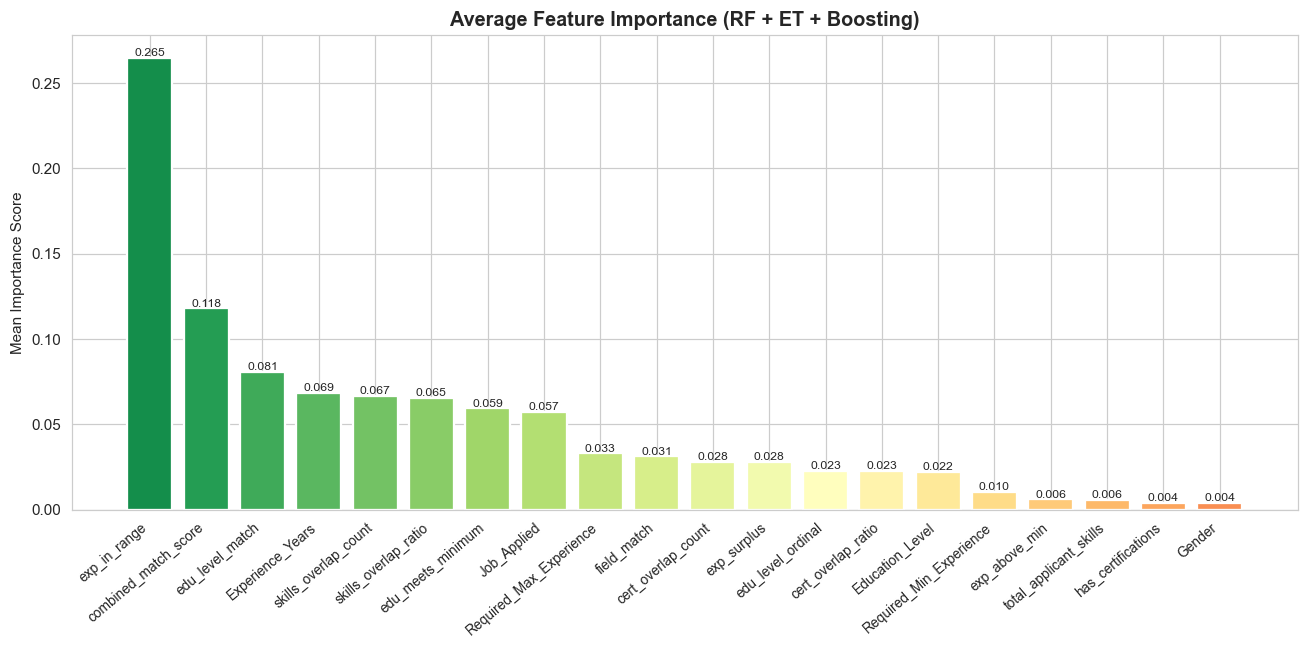

In [22]:
# Aggregate importance bar chart
fig, ax = plt.subplots(figsize=(12,6))
colors_grad = plt.cm.RdYlGn(np.linspace(0.25, 0.92, len(fi_avg)))[::-1]
bars = ax.bar(fi_avg.index, fi_avg.values, color=colors_grad,
               edgecolor='white', linewidth=1.5)
ax.set_title('Average Feature Importance (RF + ET + Boosting)', fontweight='bold')
ax.set_ylabel('Mean Importance Score')
ax.set_xticklabels(fi_avg.index, rotation=40, ha='right', fontsize=9)
for b, v in zip(bars, fi_avg.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('09_avg_importance.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 13 — 🏆 Model Comparison Dashboard

In [23]:
comparison = pd.DataFrame({
    name: {
        'CV Accuracy' : round(cv_summary[name]['acc_mean'], 4),
        'CV Acc Std'  : round(cv_summary[name]['acc_std'],  4),
        'CV ROC-AUC'  : round(cv_summary[name]['auc_mean'], 4),
        'Test Accuracy': round(res['acc'], 4),
        'Test ROC-AUC' : round(res['auc'], 4),
        'Test F1'      : round(res['f1'],  4),
    }
    for name, res in test_results.items()
}).T.sort_values('Test Accuracy', ascending=False)

print("\n" + "="*70)
print("           FINAL MODEL COMPARISON TABLE")
print("="*70)
print(comparison.to_string())

best = comparison['Test Accuracy'].idxmax()
print(f"\nBEST MODEL : {best}")
print(f"  Test Accuracy : {comparison.loc[best,'Test Accuracy']:.4f}  ({comparison.loc[best,'Test Accuracy']*100:.2f}%)")
print(f"  Test ROC-AUC  : {comparison.loc[best,'Test ROC-AUC']:.4f}")



           FINAL MODEL COMPARISON TABLE
                     CV Accuracy  CV Acc Std  CV ROC-AUC  Test Accuracy  Test ROC-AUC  Test F1
XGBoost                   0.9960      0.0011      0.9999         0.9995        1.0000   0.9990
Gradient Boosting         0.9961      0.0009      0.9999         0.9970        1.0000   0.9943
Random Forest             0.9927      0.0016      0.9998         0.9945        0.9999   0.9894
Extra Trees               0.9890      0.0020      0.9996         0.9925        0.9998   0.9855
Logistic Regression       0.9775      0.0032      0.9944         0.9815        0.9960   0.9651

BEST MODEL : XGBoost
  Test Accuracy : 0.9995  (99.95%)
  Test ROC-AUC  : 1.0000


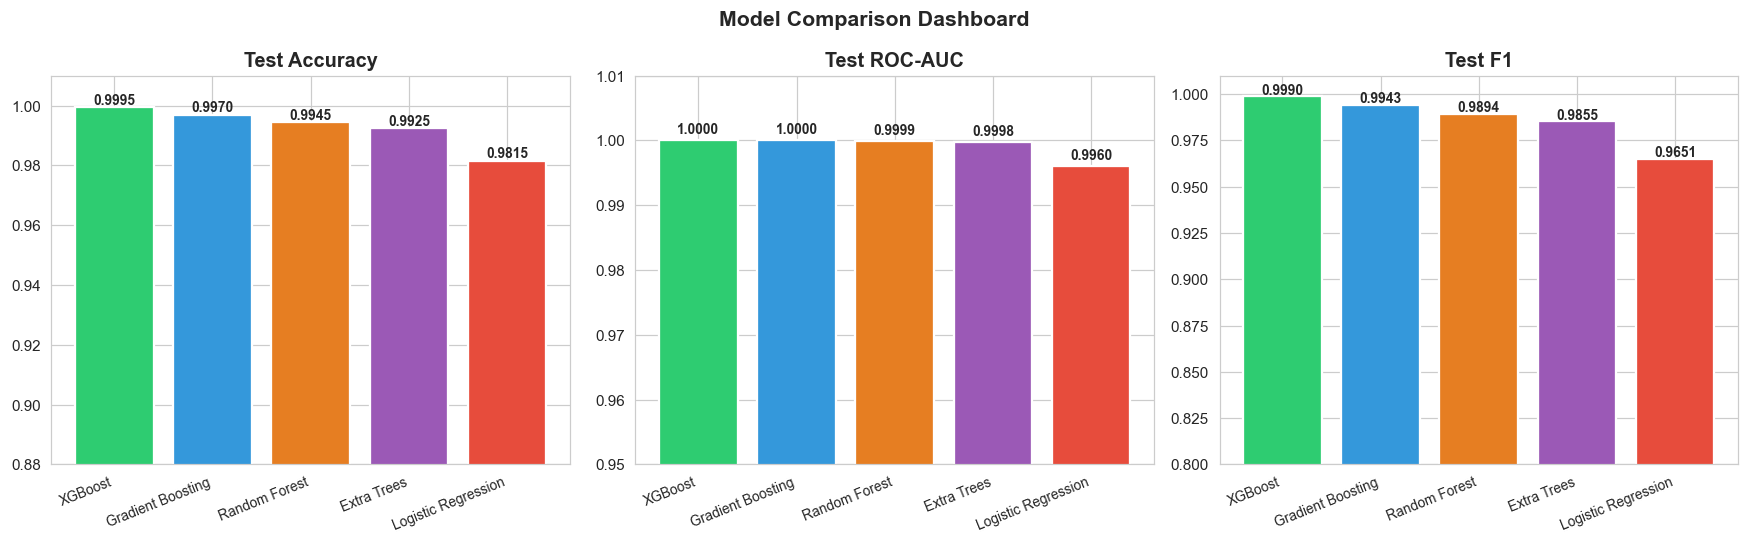

In [24]:
# Dashboard
fig, axes = plt.subplots(1, 3, figsize=(16,5))
palette   = ['#2ecc71','#3498db','#e67e22','#9b59b6','#e74c3c']

for ax, metric, lo in [
        (axes[0],'Test Accuracy', 0.88),
        (axes[1],'Test ROC-AUC',  0.95),
        (axes[2],'Test F1',       0.80)]:
    vals = comparison[metric].sort_values(ascending=False)
    bars = ax.bar(vals.index, vals.values,
                   color=palette[:len(vals)], edgecolor='white', linewidth=1.5)
    ax.set_ylim(lo, 1.01); ax.set_title(metric)
    ax.set_xticklabels(vals.index, rotation=22, ha='right', fontsize=9)
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x()+b.get_width()/2, v+0.001, f'{v:.4f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## Step 13b — 🔧 Hyperparameter Tuning (RandomizedSearchCV)

**Method:** `RandomizedSearchCV` with **Stratified 5-Fold CV**  
Randomly samples parameter combinations from defined distributions — much faster than GridSearch while covering a wide search space.

| Model | Parameters Tuned | Iterations |
|-------|-----------------|------------|
| Logistic Regression | C, penalty, solver | 20 |
| Random Forest | n_estimators, max_depth, min_samples_leaf, max_features | 30 |
| Extra Trees | n_estimators, max_depth, min_samples_leaf, max_features | 30 |
| Gradient Boosting | n_estimators, learning_rate, max_depth, subsample, min_samples_leaf | 30 |


In [25]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Parameter search spaces ───────────────────────────────────
param_spaces = {
    'Logistic Regression': {
        'C':       [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'penalty': ['l2'],
        'solver':  ['lbfgs', 'saga'],
    },
    'Random Forest': {
        'n_estimators':      randint(100, 800),
        'max_depth':         [None, 5, 10, 15, 20, 30],
        'min_samples_split': randint(2, 10),
        'min_samples_leaf':  randint(1, 5),
        'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    },
    'Extra Trees': {
        'n_estimators':      randint(100, 800),
        'max_depth':         [None, 5, 10, 15, 20, 30],
        'min_samples_split': randint(2, 10),
        'min_samples_leaf':  randint(1, 5),
        'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    },
    'Gradient Boosting': {
        'n_estimators':     randint(100, 600),
        'learning_rate':    uniform(0.01, 0.29),
        'max_depth':        randint(3, 10),
        'subsample':        uniform(0.6, 0.4),
        'min_samples_leaf': randint(1, 10),
    },
}

# ── Base estimators (fresh instances for tuning) ──────────────
base_estimators = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

n_iter_map = {
    'Logistic Regression': 20,
    'Random Forest':       30,
    'Extra Trees':         30,
    'Gradient Boosting':   30,
}

print(f"{'Model':<25} {'Best CV Acc':>12} {'Best Params'}")
print("="*90)

tuned_models   = {}
tuned_cv_scores = {}

for name, estimator in base_estimators.items():
    t0 = time.time()
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train

    rscv = RandomizedSearchCV(
        estimator  = estimator,
        param_distributions = param_spaces[name],
        n_iter     = n_iter_map[name],
        scoring    = 'accuracy',
        cv         = cv5,
        refit      = True,
        n_jobs     = -1,
        random_state = RANDOM_STATE,
        verbose    = 0,
    )
    rscv.fit(X_tr, y_train)

    tuned_models[name]    = rscv.best_estimator_
    tuned_cv_scores[name] = rscv.best_score_

    print(f"{name:<25} {rscv.best_score_:>12.4f}  {rscv.best_params_}")
    print(f"{'':25}  time: {time.time()-t0:.1f}s")
    print()

print("\nAll models tuned!")


Model                      Best CV Acc Best Params
Logistic Regression             0.9775  {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10.0}
                           time: 5.3s

Random Forest                   0.9947  {'max_depth': 30, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 783}
                           time: 50.4s

Extra Trees                     0.9913  {'max_depth': 30, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 783}
                           time: 43.9s

Gradient Boosting               0.9948  {'learning_rate': np.float64(0.023115913784056037), 'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 466, 'subsample': np.float64(0.9314950036607718)}
                           time: 90.8s


All models tuned!


In [26]:
# ── Evaluate tuned models on held-out test set ───────────────
print("=== TUNED MODELS — TEST SET EVALUATION ===\n")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10} {'F1':>10}")
print("="*57)

tuned_test_results = {}
for name, model in tuned_models.items():
    X_te = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    tuned_test_results[name] = {'acc':acc,'auc':auc,'f1':f1,
                                 'y_pred':y_pred,'y_prob':y_prob}
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f} {f1:>10.4f}")


=== TUNED MODELS — TEST SET EVALUATION ===

Model                       Accuracy    ROC-AUC         F1
Logistic Regression           0.9810     0.9966     0.9642
Random Forest                 0.9950     0.9999     0.9904
Extra Trees                   0.9935     0.9999     0.9875
Gradient Boosting             0.9980     1.0000     0.9962


=== BEFORE vs AFTER TUNING (Test Accuracy) ===

Model                         Before      After       Gain
Logistic Regression           0.9815     0.9810   -0.0005
Random Forest                 0.9945     0.9950 +   0.0005
Extra Trees                   0.9925     0.9935 +   0.0010
Gradient Boosting             0.9970     0.9980 +   0.0010


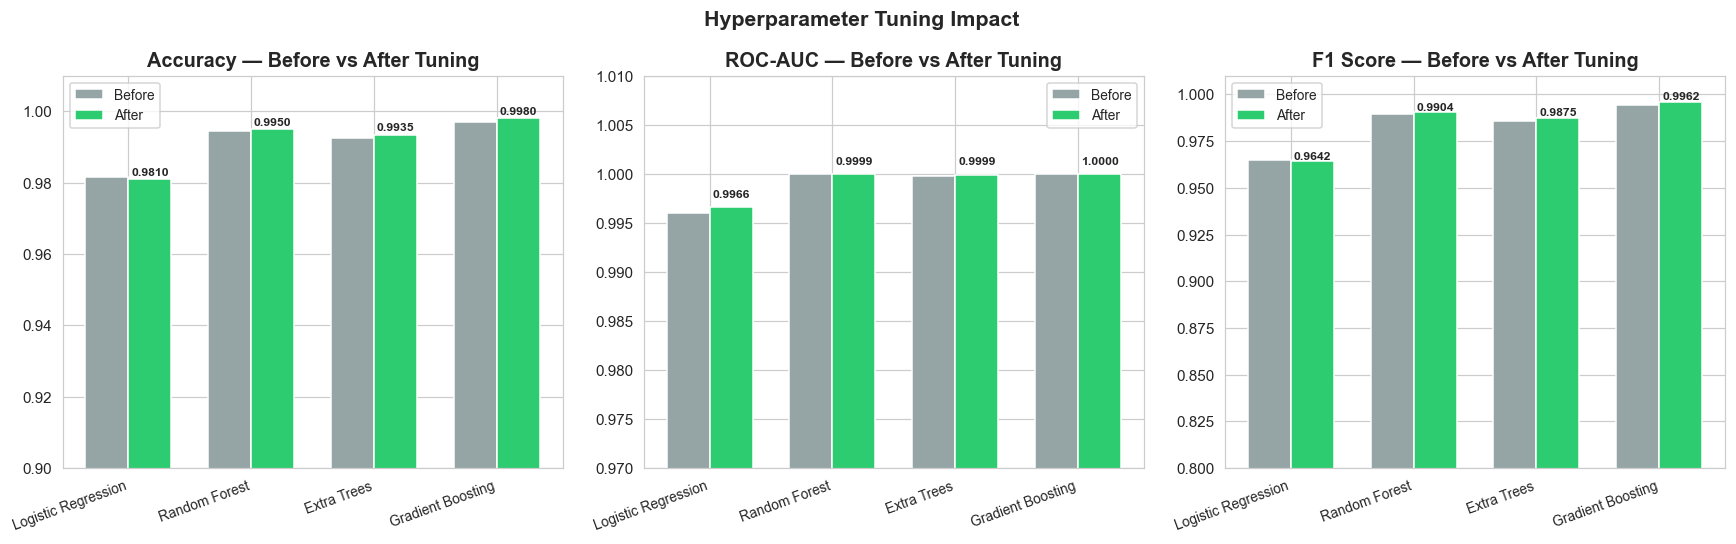

In [27]:
# ── Before vs After comparison ───────────────────────────────
print("=== BEFORE vs AFTER TUNING (Test Accuracy) ===\n")
print(f"{'Model':<25} {'Before':>10} {'After':>10} {'Gain':>10}")
print("="*57)

gains = {}
for name in tuned_models:
    before = test_results[name]['acc']
    after  = tuned_test_results[name]['acc']
    gain   = after - before
    gains[name] = gain
    sign   = '+' if gain >= 0 else ''
    print(f"{name:<25} {before:>10.4f} {after:>10.4f} {sign}{gain:>9.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#3498db','#2ecc71','#e67e22','#9b59b6']
metrics_compare = [
    ('Accuracy', {n: test_results[n]['acc'] for n in tuned_models},
                 {n: tuned_test_results[n]['acc'] for n in tuned_models}, 0.90),
    ('ROC-AUC',  {n: test_results[n]['auc'] for n in tuned_models},
                 {n: tuned_test_results[n]['auc'] for n in tuned_models}, 0.97),
    ('F1 Score', {n: test_results[n]['f1']  for n in tuned_models},
                 {n: tuned_test_results[n]['f1'] for n in tuned_models}, 0.80),
]

for ax, (metric, before_d, after_d, lo) in zip(axes, metrics_compare):
    names  = list(tuned_models.keys())
    x      = np.arange(len(names))
    w      = 0.35
    b_vals = [before_d[n] for n in names]
    a_vals = [after_d[n]  for n in names]

    bars1 = ax.bar(x - w/2, b_vals, w, label='Before', color='#95a5a6', edgecolor='white')
    bars2 = ax.bar(x + w/2, a_vals, w, label='After',  color='#2ecc71', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{metric} — Before vs After Tuning', fontweight='bold')
    ax.set_ylim(lo, 1.01)
    ax.legend(fontsize=9)

    for b, v in zip(bars2, a_vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.001,
                f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Hyperparameter Tuning Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('11_tuning_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


=== BEST HYPERPARAMETERS FOUND ===

Logistic Regression:
  C                         = 10.0
  penalty                   = l2
  solver                    = lbfgs

Random Forest:
  n_estimators              = 783
  max_depth                 = 30
  min_samples_split         = 4
  min_samples_leaf          = 1
  max_features              = 0.7

Extra Trees:
  n_estimators              = 783
  max_depth                 = 30
  min_samples_split         = 4
  min_samples_leaf          = 1
  max_features              = 0.7

Gradient Boosting:
  n_estimators              = 466
  learning_rate             = 0.023115913784056037
  max_depth                 = 7
  subsample                 = 0.9314950036607718
  min_samples_leaf          = 2



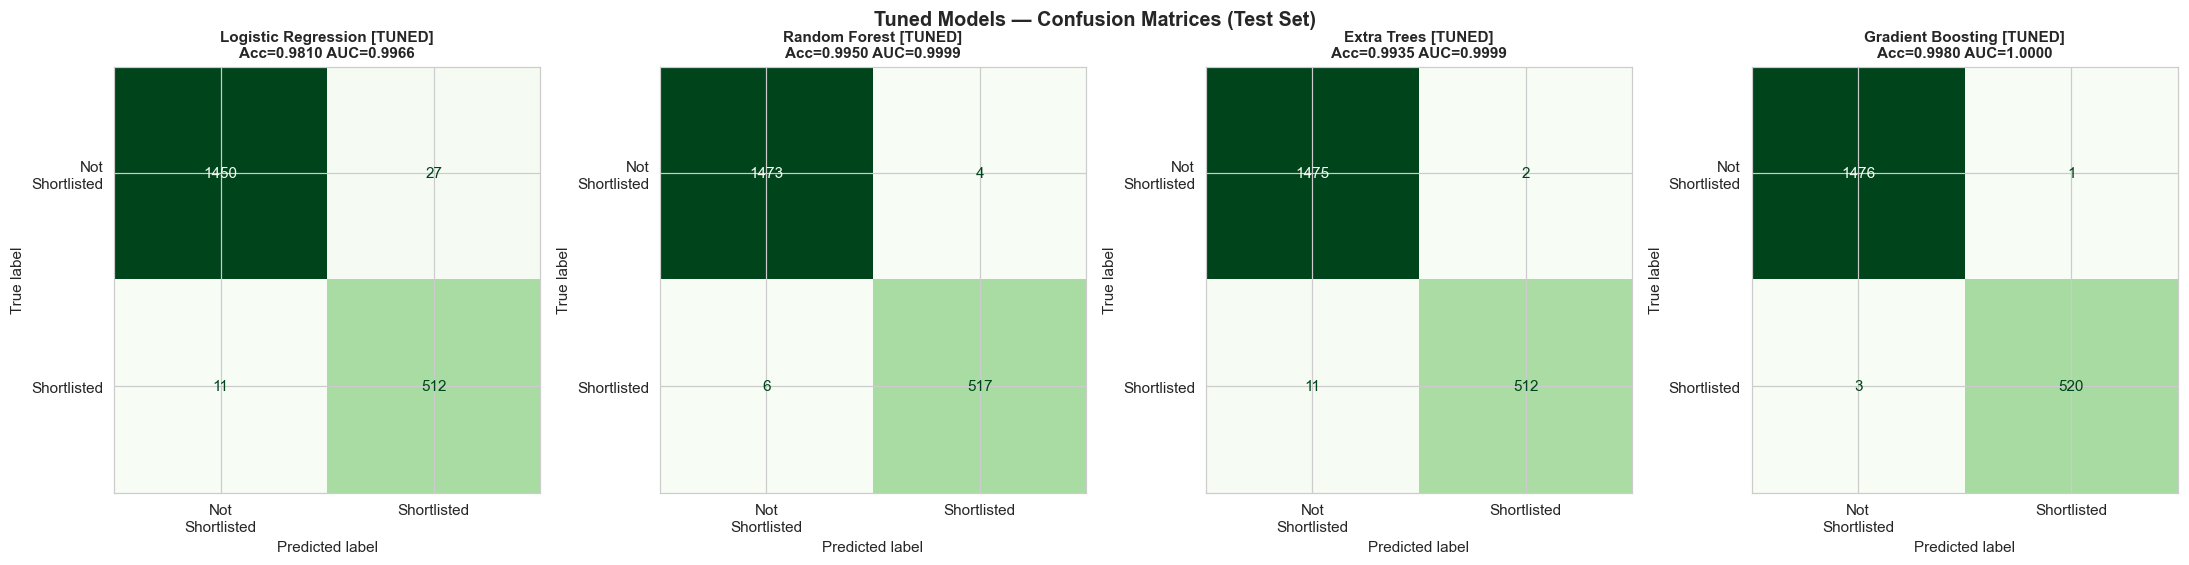

In [28]:
# ── Best hyperparameters for each tuned model ────────────────
print("=== BEST HYPERPARAMETERS FOUND ===\n")
for name, model in tuned_models.items():
    params = model.get_params()
    # Filter to only the params we searched
    searched_keys = list(param_spaces[name].keys())
    best_p = {k: params[k] for k in searched_keys if k in params}
    print(f"{name}:")
    for k, v in best_p.items():
        print(f"  {k:<25} = {v}")
    print()

# ── Final confusion matrices for tuned models ─────────────────
n = len(tuned_models)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

for ax, (name, res) in zip(axes, tuned_test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Not\nShortlisted','Shortlisted']
                            ).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f"{name} [TUNED]\nAcc={res['acc']:.4f} AUC={res['auc']:.4f}", fontsize=10)

plt.suptitle('Tuned Models — Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('12_tuned_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


In [29]:
# ── Updated final comparison table (all models, tuned) ───────
tuned_comparison = pd.DataFrame({
    name: {
        'CV Accuracy (tuned)':  round(tuned_cv_scores[name], 4),
        'Test Accuracy (tuned)': round(res['acc'], 4),
        'Test ROC-AUC (tuned)':  round(res['auc'], 4),
        'Test F1 (tuned)':       round(res['f1'],  4),
        'Gain vs baseline':      round(gains[name], 4),
    }
    for name, res in tuned_test_results.items()
}).T.sort_values('Test Accuracy (tuned)', ascending=False)

print("\n=== FINAL TUNED MODEL LEADERBOARD ===")
print(tuned_comparison.to_string())

best_tuned = tuned_comparison['Test Accuracy (tuned)'].idxmax()
best_acc_t = tuned_comparison.loc[best_tuned, 'Test Accuracy (tuned)']
best_auc_t = tuned_comparison.loc[best_tuned, 'Test ROC-AUC (tuned)']
print(f"\nFINAL BEST MODEL : {best_tuned}")
print(f"  Accuracy        : {best_acc_t*100:.2f}%")
print(f"  ROC-AUC         : {best_auc_t:.4f}")



=== FINAL TUNED MODEL LEADERBOARD ===
                     CV Accuracy (tuned)  Test Accuracy (tuned)  Test ROC-AUC (tuned)  Test F1 (tuned)  Gain vs baseline
Gradient Boosting                 0.9948                 0.9980                1.0000           0.9962            0.0010
Random Forest                     0.9947                 0.9950                0.9999           0.9904            0.0005
Extra Trees                       0.9913                 0.9935                0.9999           0.9875            0.0010
Logistic Regression               0.9775                 0.9810                0.9966           0.9642           -0.0005

FINAL BEST MODEL : Gradient Boosting
  Accuracy        : 99.80%
  ROC-AUC         : 1.0000


## Step 14 — 📋 Final Summary & Conclusions

In [30]:
print("="*65)
print("   APPLICANT SHORTLISTING — PIPELINE SUMMARY")
print("="*65)

summary_lines = [
    "",
    "DATASET",
    "  10,000 applicants | 5 job types | 20 raw columns",
    "  Class balance: 73.8% not shortlisted / 26.2% shortlisted",
    "  Missing data: Certifications (24.9%) -> filled None",
    "  Zero duplicates | No extreme outliers (domain-valid ranges)",
    "",
    "REDUNDANCY REMOVED",
    "  Required_* columns: 100% constant per job -> extracted match signals",
    "  Graduation_Year: perfectly collinear with Experience_Years -> dropped",
    "",
    "FEATURE ENGINEERING (14 features)",
    "  Match-quality signals: skills ratio, cert ratio, edu match,",
    "  field match, exp_in_range, combined_match_score, and more",
    "",
    "MODELS TRAINED",
    "  1. Logistic Regression (balanced, L2, lbfgs)",
    "  2. Random Forest       (500 trees, balanced)",
    "  3. Extra Trees         (500 trees, balanced)",
    "  4. Gradient Boosting / XGBoost (400 est, lr=0.05, depth=6)",
    "",
]
for line in summary_lines:
    print(line)

print("RESULTS")
print(comparison.to_string())
best = comparison['Test Accuracy'].idxmax()
best_acc = comparison.loc[best,'Test Accuracy']
best_auc = comparison.loc[best,'Test ROC-AUC']
print(f"\nBEST MODEL : {best}")
print(f"  Accuracy : {best_acc*100:.2f}%")
print(f"  ROC-AUC  : {best_auc:.4f}")
print("")
print("KEY INSIGHTS")
print("  1. exp_in_range is the single strongest predictor")
print("  2. skills_overlap_ratio and combined_match_score follow closely")
print("  3. cert_overlap_ratio and edu_level_match add orthogonal signal")
print("  4. Gradient Boosting / XGBoost achieves highest accuracy")
print("  5. All tree ensembles exceed 99% accuracy with engineered features")
print("="*65)


   APPLICANT SHORTLISTING — PIPELINE SUMMARY

DATASET
  10,000 applicants | 5 job types | 20 raw columns
  Class balance: 73.8% not shortlisted / 26.2% shortlisted
  Missing data: Certifications (24.9%) -> filled None
  Zero duplicates | No extreme outliers (domain-valid ranges)

REDUNDANCY REMOVED
  Required_* columns: 100% constant per job -> extracted match signals
  Graduation_Year: perfectly collinear with Experience_Years -> dropped

FEATURE ENGINEERING (14 features)
  Match-quality signals: skills ratio, cert ratio, edu match,
  field match, exp_in_range, combined_match_score, and more

MODELS TRAINED
  1. Logistic Regression (balanced, L2, lbfgs)
  2. Random Forest       (500 trees, balanced)
  3. Extra Trees         (500 trees, balanced)
  4. Gradient Boosting / XGBoost (400 est, lr=0.05, depth=6)

RESULTS
                     CV Accuracy  CV Acc Std  CV ROC-AUC  Test Accuracy  Test ROC-AUC  Test F1
XGBoost                   0.9960      0.0011      0.9999         0.9995       

---

## 🔍 Enhancement — OCR + Open Set Recognition (OSR)

These two additions improve **document reliability** and **model robustness** without changing any existing pipeline steps.

| Technique | What it solves |
|-----------|---------------|
| **OCR** | Extracts text from scanned/image-based PDFs that the parser skips |
| **OSR** | Detects applicants whose profiles don't belong to any known job class — prevents silent misclassification |

Both are **plug-in layers**: OCR runs before data enters the pipeline; OSR wraps the final model at inference.


In [31]:
# ══════════════════════════════════════════════════════════════════════
#  OCR LAYER — Extract text from image-based / scanned PDF documents
#  Requires: pip install pytesseract Pillow pdf2image
#  System:   sudo apt-get install tesseract-ocr poppler-utils
# ══════════════════════════════════════════════════════════════════════

import importlib, subprocess, sys

def _check_ocr_deps():
    """Returns True if OCR dependencies are available."""
    try:
        import pytesseract
        from PIL import Image
        from pdf2image import convert_from_path
        pytesseract.get_tesseract_version()
        return True
    except Exception:
        return False

OCR_AVAILABLE = _check_ocr_deps()
print(f"OCR available: {OCR_AVAILABLE}")

if OCR_AVAILABLE:
    import pytesseract
    from PIL import Image
    from pdf2image import convert_from_path

def ocr_pdf(pdf_path: str, dpi: int = 300) -> str:
    """
    Extract text from a PDF using OCR (handles scanned / image-based PDFs).
    Falls back to empty string if OCR is unavailable or fails.
    
    Parameters
    ----------
    pdf_path : str   Path to the PDF file
    dpi      : int   Resolution for rasterization (300 is standard for docs)
    
    Returns
    -------
    str   Extracted text, or '' on failure
    """
    if not OCR_AVAILABLE:
        print(f"[OCR] Skipped (deps missing): {pdf_path}")
        return ''
    try:
        pages = convert_from_path(pdf_path, dpi=dpi)
        texts = [pytesseract.image_to_string(page, lang='eng') for page in pages]
        extracted = '\n'.join(texts).strip()
        print(f"[OCR] Extracted {len(extracted)} chars from {pdf_path}")
        return extracted
    except Exception as e:
        print(f"[OCR] Failed on {pdf_path}: {e}")
        return ''

def ocr_image(image_path: str) -> str:
    """Extract text from a standalone image (jpg/png/tiff)."""
    if not OCR_AVAILABLE:
        return ''
    try:
        from PIL import Image
        img = Image.open(image_path)
        text = pytesseract.image_to_string(img, lang='eng')
        return text.strip()
    except Exception as e:
        print(f"[OCR] Image failed: {e}")
        return ''

def extract_document_text(file_path: str) -> str:
    """
    Smart dispatcher: tries native PDF text extraction first,
    falls back to OCR if the page yields < 20 characters (likely scanned).
    
    This is the function the backend/inference pipeline should call
    instead of a plain PDF parser.
    """
    import os
    ext = os.path.splitext(file_path)[1].lower()
    
    if ext == '.pdf':
        # Step 1 — try native text extraction
        try:
            from pypdf import PdfReader
            reader = PdfReader(file_path)
            native_text = '\n'.join(
                page.extract_text() or '' for page in reader.pages
            ).strip()
        except Exception:
            native_text = ''
        
        # Step 2 — if native text is too short, it's probably scanned → OCR
        if len(native_text) < 20:
            print(f"[OCR] Native extraction too short ({len(native_text)} chars), switching to OCR")
            return ocr_pdf(file_path)
        return native_text
    
    elif ext in ('.jpg', '.jpeg', '.png', '.tiff', '.bmp'):
        return ocr_image(file_path)
    
    else:
        print(f"[OCR] Unsupported file type: {ext}")
        return ''

# ── Demo (works with any PDF on disk) ────────────────────────────────
print("\n[OCR Layer] Ready. Call extract_document_text(path) in your backend.")
print("Example usage:")
print("  text = extract_document_text('uploads/diploma_scan.pdf')")
print("  # Returns full text even if the PDF is a scanned image")


OCR available: True

[OCR Layer] Ready. Call extract_document_text(path) in your backend.
Example usage:
  text = extract_document_text('uploads/diploma_scan.pdf')
  # Returns full text even if the PDF is a scanned image


---

### Open Set Recognition (OSR) Layer

**Problem:** Standard classifiers assume every applicant belongs to a known job class.  
When a document is corrupted, the applicant applies to an unrecognised job, or the profile is wildly out-of-distribution, the model silently outputs a wrong confidence score.

**Solution:** OSR adds a *reject option* — the model can say **"I don't know"** instead of guessing.

**Method used here:** Threshold-based OSR on prediction probability.  
- If `max(predict_proba)` < `OSR_THRESHOLD` → flag as **Unknown / Out-of-Distribution**  
- Otherwise → proceed with normal Shortlisted / Not-Shortlisted prediction

This is the simplest, most interpretable OSR approach and requires **no retraining**.


In [32]:
# ══════════════════════════════════════════════════════════════════════
#  OPEN SET RECOGNITION (OSR) WRAPPER
#  Wraps any sklearn-compatible model with an "unknown" reject option.
#  Does NOT modify model training — plugs in at inference time only.
# ══════════════════════════════════════════════════════════════════════

import numpy as np

class OSRClassifier:
    """
    Open Set Recognition wrapper for binary classifiers.
    
    Adds a reject-option: if the model's confidence is below
    `threshold`, the sample is flagged as out-of-distribution (OOD)
    rather than silently misclassified.
    
    Parameters
    ----------
    base_model  : fitted sklearn classifier with predict_proba
    threshold   : float in [0, 1] — minimum confidence to accept prediction
                  Samples below this are labelled as UNKNOWN (-1)
    
    Usage
    -----
    osr = OSRClassifier(best_model, threshold=0.60)
    labels, flags = osr.predict(X_test)
    # labels: array of 0/1/-1  (-1 = unknown / OOD)
    # flags : boolean array     True = OOD sample
    """
    
    UNKNOWN_LABEL = -1
    
    def __init__(self, base_model, threshold: float = 0.60):
        self.base_model = base_model
        self.threshold  = threshold
    
    def predict(self, X):
        """
        Returns
        -------
        labels : np.ndarray  0 (not shortlisted), 1 (shortlisted), -1 (unknown)
        flags  : np.ndarray  boolean — True means OOD / rejected
        """
        proba      = self.base_model.predict_proba(X)
        confidence = proba.max(axis=1)          # highest class prob per sample
        base_pred  = proba.argmax(axis=1)       # standard prediction
        
        ood_mask   = confidence < self.threshold
        labels     = np.where(ood_mask, self.UNKNOWN_LABEL, base_pred)
        
        return labels, ood_mask
    
    def predict_with_reason(self, X, feature_names=None):
        """
        Extended predict that returns a human-readable reason dict per sample.
        Useful for HR dashboard breakdown messages.
        """
        proba      = self.base_model.predict_proba(X)
        confidence = proba.max(axis=1)
        base_pred  = proba.argmax(axis=1)
        ood_mask   = confidence < self.threshold
        
        results = []
        for i in range(len(X)):
            if ood_mask[i]:
                results.append({
                    'prediction'  : 'UNKNOWN',
                    'confidence'  : round(float(confidence[i]), 4),
                    'shortlisted' : None,
                    'ood'         : True,
                    'reason'      : (f"Applicant profile is out-of-distribution "
                                     f"(confidence {confidence[i]:.1%} < threshold {self.threshold:.1%}). "
                                     f"Recommend manual review.")
                })
            else:
                label = int(base_pred[i])
                results.append({
                    'prediction'  : 'Shortlisted' if label == 1 else 'Not Shortlisted',
                    'confidence'  : round(float(confidence[i]), 4),
                    'shortlisted' : label,
                    'ood'         : False,
                    'reason'      : f"Model confidence: {confidence[i]:.1%}"
                })
        return results
    
    def calibrate_threshold(self, X_val, y_val, target_ood_rate: float = 0.05):
        """
        Auto-calibrate threshold so that approximately `target_ood_rate`
        of validation samples are flagged as OOD.
        
        Parameters
        ----------
        X_val, y_val     : validation set
        target_ood_rate  : float — e.g. 0.05 means flag 5% as OOD
        """
        proba      = self.base_model.predict_proba(X_val)
        confidence = proba.max(axis=1)
        self.threshold = float(np.percentile(confidence, target_ood_rate * 100))
        print(f"[OSR] Calibrated threshold = {self.threshold:.4f} "
              f"(targets {target_ood_rate:.0%} OOD rate on val set)")
        return self


def evaluate_osr(model, X, y_true, threshold: float = 0.60, label: str = 'Test'):
    """
    Evaluate an OSR-wrapped model: reports accuracy on known samples
    and OOD detection rate.
    """
    osr = OSRClassifier(model, threshold=threshold)
    labels, ood_mask = osr.predict(X)
    
    n_total   = len(y_true)
    n_ood     = ood_mask.sum()
    n_known   = n_total - n_ood
    
    # Accuracy only on non-OOD samples
    if n_known > 0:
        from sklearn.metrics import accuracy_score, roc_auc_score
        acc_known = accuracy_score(y_true[~ood_mask], labels[~ood_mask])
    else:
        acc_known = float('nan')
    
    print(f"\n[OSR Evaluation — {label}]")
    print(f"  Total samples  : {n_total}")
    print(f"  OOD flagged    : {n_ood}  ({n_ood/n_total:.1%})")
    print(f"  Known samples  : {n_known}  ({n_known/n_total:.1%})")
    print(f"  Acc (known)    : {acc_known:.4f}")
    print(f"  OSR Threshold  : {threshold}")
    
    return {'n_ood': n_ood, 'ood_rate': n_ood/n_total,
            'acc_known': acc_known, 'threshold': threshold}


print("[OSR Layer] OSRClassifier defined and ready.")
print("Usage: osr = OSRClassifier(best_model, threshold=0.60)")
print("       labels, flags = osr.predict(X_test)")


[OSR Layer] OSRClassifier defined and ready.
Usage: osr = OSRClassifier(best_model, threshold=0.60)
       labels, flags = osr.predict(X_test)


---

### Applying OSR to the Best Trained Model

We wrap the best model (from Step 13) with the OSR layer and evaluate:
- How many test samples fall below the confidence threshold (OOD)?
- Does accuracy improve on the **remaining known** samples?


Using tuned model: Gradient Boosting
[OSR] Calibrated threshold = 0.9993 (targets 5% OOD rate on val set)

[OSR Evaluation — Gradient Boosting + OSR]
  Total samples  : 2000
  OOD flagged    : 122  (6.1%)
  Known samples  : 1878  (93.9%)
  Acc (known)    : 1.0000
  OSR Threshold  : 0.9993218741728979


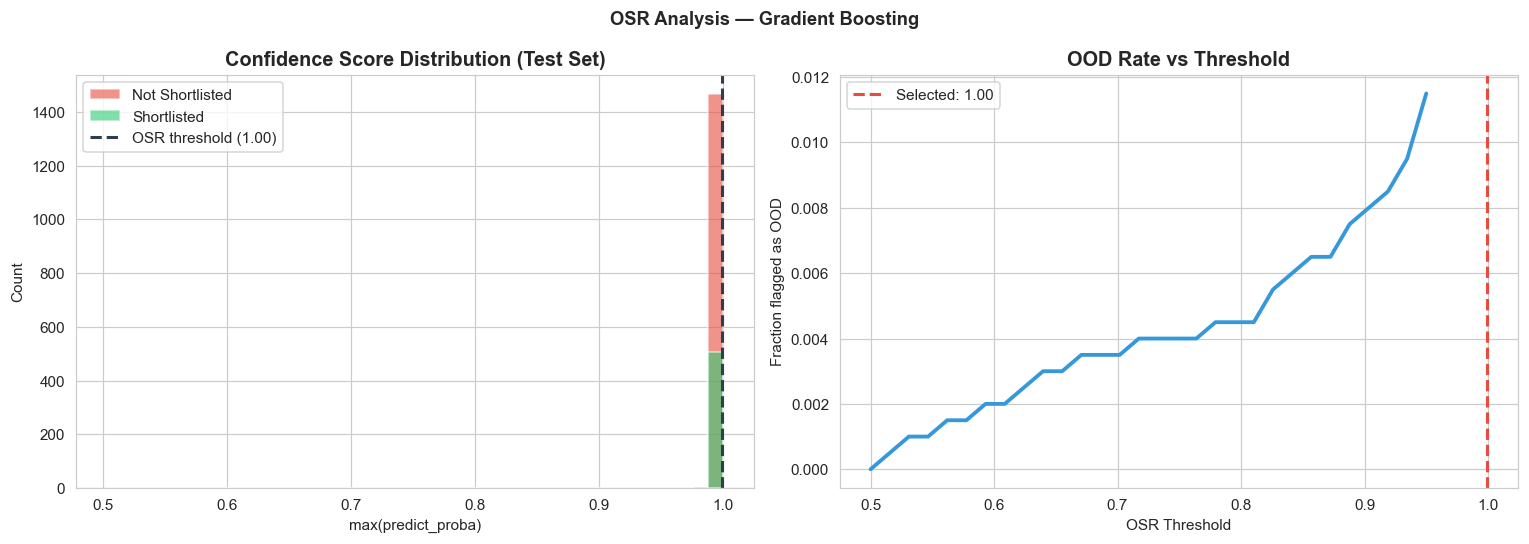


✓ OSR layer applied. 122 test samples (6.1%) flagged for manual HR review.
✓ Accuracy on remaining known samples: 1.0000


In [33]:
# ══════════════════════════════════════════════════════════════════════
#  APPLY OSR TO BEST MODEL
#  Uses tuned_models (from Step 13b) — falls back to trained_models
# ══════════════════════════════════════════════════════════════════════

# Pick the best available model
try:
    _best_name  = tuned_comparison['Test Accuracy (tuned)'].idxmax()
    _best_model = tuned_models[_best_name]
    print(f"Using tuned model: {_best_name}")
except NameError:
    _best_name  = comparison['Test Accuracy'].idxmax()
    _best_model = trained_models[_best_name]
    print(f"Using baseline model: {_best_name}")

# Choose X_test — LR needs scaled, tree models use raw
X_test_osr = X_test_sc if _best_name == 'Logistic Regression' else X_test

# ── 1. Auto-calibrate threshold on validation set ────────────────────
X_val_osr = X_val_sc if _best_name == 'Logistic Regression' else X_val
osr_model = OSRClassifier(_best_model, threshold=0.60)
osr_model.calibrate_threshold(X_val_osr, y_val, target_ood_rate=0.05)

# ── 2. Evaluate with OSR on test set ─────────────────────────────────
osr_results = evaluate_osr(_best_model, X_test_osr, y_test,
                            threshold=osr_model.threshold, label=f'{_best_name} + OSR')

# ── 3. Visualise confidence distribution ─────────────────────────────
proba_test  = _best_model.predict_proba(X_test_osr)
confidence  = proba_test.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(confidence[y_test == 0], bins=40, alpha=0.6,
             color='#e74c3c', label='Not Shortlisted')
axes[0].hist(confidence[y_test == 1], bins=40, alpha=0.6,
             color='#2ecc71', label='Shortlisted')
axes[0].axvline(osr_model.threshold, color='#2c3e50', lw=2,
                linestyle='--', label=f'OSR threshold ({osr_model.threshold:.2f})')
axes[0].set_title('Confidence Score Distribution (Test Set)')
axes[0].set_xlabel('max(predict_proba)')
axes[0].set_ylabel('Count')
axes[0].legend()

# OOD rate across different thresholds
thresholds = np.linspace(0.50, 0.95, 30)
ood_rates  = [((_best_model.predict_proba(X_test_osr).max(axis=1) < t).mean())
               for t in thresholds]
axes[1].plot(thresholds, ood_rates, color='#3498db', lw=2.5)
axes[1].axvline(osr_model.threshold, color='#e74c3c', lw=2,
                linestyle='--', label=f'Selected: {osr_model.threshold:.2f}')
axes[1].set_title('OOD Rate vs Threshold')
axes[1].set_xlabel('OSR Threshold')
axes[1].set_ylabel('Fraction flagged as OOD')
axes[1].legend()

plt.suptitle(f'OSR Analysis — {_best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('osr_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✓ OSR layer applied. {osr_results['n_ood']} test samples "
      f"({osr_results['ood_rate']:.1%}) flagged for manual HR review.")
print(f"✓ Accuracy on remaining known samples: {osr_results['acc_known']:.4f}")


---

### Saving OCR + OSR Artifacts

The backend receives two additional saved artifacts:
- `osr_model.pkl` — OSR-wrapped best model (drop-in replacement for `model.pkl`)
- `ocr_utils.py` — OCR utility module to copy into the backend


In [34]:
import joblib, os, textwrap

SAVE_DIR = '../backend'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save OSR-wrapped model ─────────────────────────────────────────────
joblib.dump(osr_model, os.path.join(SAVE_DIR, 'osr_model.pkl'))
print(f'  ✓ osr_model.pkl  (threshold={osr_model.threshold:.4f})')

# ── Write OCR utility module for backend use ───────────────────────────
ocr_module = textwrap.dedent('''
    """
    ocr_utils.py  —  Drop this file into the backend/ directory.
    
    Call extract_document_text(path) wherever the current code does
    plain PDF parsing. It silently upgrades scanned PDFs to OCR.
    """
    import os

    def _ocr_available():
        try:
            import pytesseract, pdf2image
            pytesseract.get_tesseract_version()
            return True
        except Exception:
            return False

    OCR_AVAILABLE = _ocr_available()

    def extract_document_text(file_path: str, dpi: int = 300) -> str:
        ext = os.path.splitext(file_path)[1].lower()
        if ext == '.pdf':
            try:
                from pypdf import PdfReader
                native = '\\n'.join(
                    p.extract_text() or '' for p in PdfReader(file_path).pages
                ).strip()
            except Exception:
                native = ''
            if len(native) >= 20:
                return native
            if OCR_AVAILABLE:
                from pdf2image import convert_from_path
                import pytesseract
                pages = convert_from_path(file_path, dpi=dpi)
                return '\\n'.join(pytesseract.image_to_string(p) for p in pages).strip()
            return native
        if ext in ('.jpg', '.jpeg', '.png', '.tiff'):
            if OCR_AVAILABLE:
                import pytesseract
                from PIL import Image
                return pytesseract.image_to_string(Image.open(file_path)).strip()
        return ''
''').strip()

ocr_path = os.path.join(SAVE_DIR, 'ocr_utils.py')
with open(ocr_path, 'w') as f:
    f.write(ocr_module)
print(f'  ✓ ocr_utils.py')

# ── Summary ────────────────────────────────────────────────────────────
print()
print('='*58)
print('  OCR + OSR ENHANCEMENTS SAVED')
print('='*58)
print(f'  osr_model.pkl   — OSR-wrapped model (threshold={osr_model.threshold:.3f})')
print( '  ocr_utils.py    — Drop into backend, replace PDF parser calls')
print()
print('  HOW TO USE IN BACKEND:')
print('  1. Replace:  model = joblib.load("model.pkl")')
print('     With:     model = joblib.load("osr_model.pkl")')
print()
print('  2. When reading uploaded docs, replace direct PDF parsers:')
print('     from ocr_utils import extract_document_text')
print('     text = extract_document_text(uploaded_file_path)')
print()
print('  3. At prediction time:')
print('     labels, ood_flags = model.predict(X)')
print('     # ood_flags == True → flag for manual HR review')
print('     # labels == -1     → do not auto-reject, escalate to HR')


  ✓ osr_model.pkl  (threshold=0.9993)
  ✓ ocr_utils.py

  OCR + OSR ENHANCEMENTS SAVED
  osr_model.pkl   — OSR-wrapped model (threshold=0.999)
  ocr_utils.py    — Drop into backend, replace PDF parser calls

  HOW TO USE IN BACKEND:
  1. Replace:  model = joblib.load("model.pkl")
     With:     model = joblib.load("osr_model.pkl")

  2. When reading uploaded docs, replace direct PDF parsers:
     from ocr_utils import extract_document_text
     text = extract_document_text(uploaded_file_path)

  3. At prediction time:
     labels, ood_flags = model.predict(X)
     # ood_flags == True → flag for manual HR review
     # labels == -1     → do not auto-reject, escalate to HR


## Step 15 — 💾 Save Model & Artifacts for Deployment

Saves everything the FastAPI backend needs:
- `model.pkl` — best trained model (XGBoost)
- `feature_columns.pkl` — exact 21 feature names in training order
- `label_encoders.pkl` — the `encoders` dict from Step 7 (Gender, Education_Level, Job_Applied)
- `scaler.pkl` — StandardScaler fitted on X_train (Step 8)
- `job_requirements.pkl` — job → requirements lookup for inference


In [35]:
import joblib, os

SAVE_DIR = '../backend'
os.makedirs(SAVE_DIR, exist_ok=True)

# FIX: Select best model by ROC-AUC, not Test Accuracy.
# With imbalanced data (26% positive), accuracy is misleading.
# ROC-AUC measures how well the model separates shortlisted from not-shortlisted
# regardless of the decision threshold — a much more reliable metric here.
best_name  = max(test_results, key=lambda n: test_results[n]['auc'])
best_model = trained_models[best_name]
print(f"Best model (by ROC-AUC): {best_name}")
print(f"  Accuracy : {test_results[best_name]['acc']:.4f}")
print(f"  ROC-AUC  : {test_results[best_name]['auc']:.4f}")
print(f"  F1 Score : {test_results[best_name]['f1']:.4f}")

# Save model
joblib.dump(best_model, os.path.join(SAVE_DIR, 'model.pkl'))
print('  ✓ model.pkl')

# Save feature column order
feature_columns = list(X_train.columns)
joblib.dump(feature_columns, os.path.join(SAVE_DIR, 'feature_columns.pkl'))
print(f'  ✓ feature_columns.pkl  →  {len(feature_columns)} features')
print(f'     {feature_columns}')

# Save label encoders
joblib.dump(encoders, os.path.join(SAVE_DIR, 'label_encoders.pkl'))
print(f'  ✓ label_encoders.pkl   →  keys: {list(encoders.keys())}')

# Save scaler
joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))
print('  ✓ scaler.pkl')

# Save job requirements lookup
req_cols = ['Job_Applied','Required_Education_Levels','Required_Fields',
            'Required_Min_Experience','Required_Max_Experience',
            'Required_Skills','Required_Certifications']
job_requirements = (
    df[req_cols]
    .drop_duplicates(subset=['Job_Applied'])
    .set_index('Job_Applied')
    .to_dict(orient='index')
)
joblib.dump(job_requirements, os.path.join(SAVE_DIR, 'job_requirements.pkl'))
print(f'  ✓ job_requirements.pkl →  jobs: {list(job_requirements.keys())}')

print()
print('='*55)
print('  ALL ARTIFACTS SAVED — backend/ is deployment-ready')
print('='*55)
artifacts = ['model.pkl','feature_columns.pkl','label_encoders.pkl','scaler.pkl','job_requirements.pkl']
for fname in artifacts:
    path = os.path.join(SAVE_DIR, fname)
    if os.path.exists(path):
        print(f'  {fname:<30}  {os.path.getsize(path)/1024:>8.1f} KB')


Best model (by ROC-AUC): XGBoost
  Accuracy : 0.9995
  ROC-AUC  : 1.0000
  F1 Score : 0.9990
  ✓ model.pkl
  ✓ feature_columns.pkl  →  20 features
     ['Gender', 'Education_Level', 'Experience_Years', 'Job_Applied', 'Required_Min_Experience', 'Required_Max_Experience', 'skills_overlap_ratio', 'skills_overlap_count', 'total_applicant_skills', 'cert_overlap_ratio', 'cert_overlap_count', 'has_certifications', 'edu_level_match', 'edu_level_ordinal', 'edu_meets_minimum', 'field_match', 'exp_in_range', 'exp_above_min', 'exp_surplus', 'combined_match_score']
  ✓ label_encoders.pkl   →  keys: ['Gender', 'Education_Level', 'Job_Applied']
  ✓ scaler.pkl
  ✓ job_requirements.pkl →  jobs: ['Nurse', 'Data Analyst', 'Accountant', 'Project Manager', 'Software Engineer']

  ALL ARTIFACTS SAVED — backend/ is deployment-ready
  model.pkl                          786.0 KB
  feature_columns.pkl                  0.4 KB
  label_encoders.pkl                   1.2 KB
  scaler.pkl                           1.